# Prototype-Based Open-Set Product Recognition
## MVTec Surface Class Recognition - Backbone and Distance Metric Comparison

**Backbones compared:** MobileNetV3-Small vs ResNet-18  
**Distance metrics compared:** Cosine Similarity vs Multi-Prototype  
**Training:** Cross-Entropy + Supervised Contrastive Loss + Synthetic Defect Augmentation  
**Random Seed:** 42  

---


## 1. Dependencies and Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys
packages = [
    'torch', 'torchvision', 'opencv-python',
    'scikit-learn', 'matplotlib', 'seaborn',
    'pandas', 'numpy', 'Pillow', 'ipywidgets', 'tqdm', 'tabulate'
]
for pkg in packages:
    try:
        __import__(pkg.replace('-','_').split('==')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [3]:
import os, random, copy, time, warnings, io
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from PIL import Image, ImageFilter, ImageDraw
from tqdm.notebook import tqdm
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Configuration

In [4]:
# ============================================================
# USER PATHS - edit before running
# ============================================================
CHECKPOINT_DIR      = '/content/drive/MyDrive/C_checkpoints'
EXTERNAL_IMAGES_DIR = '/content/drive/MyDrive/Colab Notebooks/ICT304/dataset'

KNOWN_CLASSES = ['leather', 'tile', 'wood', 'grid', 'carpet']


os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print('Configuration loaded.')


import os, glob, shutil, tarfile

DRIVE_TAR_DIR = '/content/drive/MyDrive/Colab Notebooks/ICT304/object_class'
LOCAL_EXTRACT = '/content/mvtec'

os.makedirs(LOCAL_EXTRACT, exist_ok=True)

tar_files = (
    glob.glob(os.path.join(DRIVE_TAR_DIR, '*.tar.xz')) +
    glob.glob(os.path.join(DRIVE_TAR_DIR, '*.tgz'))    +
    glob.glob(os.path.join(DRIVE_TAR_DIR, '*.tar'))
)

print(f'Found {len(tar_files)} compressed files:')
for f in tar_files:
    print(f'  {os.path.basename(f)}')

for tar_path in tar_files:
    fname      = os.path.basename(tar_path)
    local_copy = f'/content/{fname}'

    # Copy from Drive to local SSD (much faster to extract locally)
    print(f'\nCopying {fname} ...')
    shutil.copy2(tar_path, local_copy)

    # Extract
    print(f'Extracting {fname} ...')
    with tarfile.open(local_copy, 'r:*') as tar:
        tar.extractall(LOCAL_EXTRACT)

    # Delete compressed copy immediately to save space
    os.remove(local_copy)
    print(f'Done. Removed local copy.')

print('\nExtracted contents:')
for item in sorted(os.listdir(LOCAL_EXTRACT)):
    print(f'  {item}')

Configuration loaded.
Found 5 compressed files:
  grid.tar.xz
  tile.tar.xz
  wood.tar.xz
  leather.tar.xz
  carpet.tar.xz

Copying grid.tar.xz ...
Extracting grid.tar.xz ...
Done. Removed local copy.

Copying tile.tar.xz ...
Extracting tile.tar.xz ...
Done. Removed local copy.

Copying wood.tar.xz ...
Extracting wood.tar.xz ...
Done. Removed local copy.

Copying leather.tar.xz ...
Extracting leather.tar.xz ...
Done. Removed local copy.

Copying carpet.tar.xz ...
Extracting carpet.tar.xz ...
Done. Removed local copy.

Extracted contents:
  carpet
  grid
  leather
  tile
  wood


In [5]:
MVTEC_ROOT = '/content/mvtec'

In [6]:
# ============================================================
# HYPERPARAMETERS
# ============================================================
IMG_SIZE               = 224
EMBEDDING_DIM          = 128
DROPOUT                = 0.2
BATCH_SIZE             = 32
EPOCHS_WARMUP          = 5
EPOCHS_FINETUNE        = 20
LR_HEAD_WARMUP         = 1e-3
LR_FINETUNE            = 1e-4
LR_BACKBONE_FINETUNE   = 5e-5
WEIGHT_DECAY           = 1e-4
EARLY_STOPPING_PATIENCE = 7
LAMBDA_CE              = 1.0
LAMBDA_SUPCON          = 0.3
SUPCON_TEMPERATURE     = 0.07
CONFIDENCE_THRESHOLD   = 0.70
MARGIN_THRESHOLD       = 0.05
NUM_SYNTHETIC          = 3

## 3. Augmentation and Transforms

In [7]:
class RegionLevelNormalize:
    """
    Applies local contrast normalization to random patches.
    Reduces model dependence on global texture that defects disrupt.
    """
    def __init__(self, num_regions=4, region_size_ratio=(0.1, 0.25)):
        self.num_regions = num_regions
        self.region_size_ratio = region_size_ratio

    def __call__(self, t):
        C, H, W = t.shape
        out = t.clone()
        for _ in range(self.num_regions):
            rh = random.uniform(*self.region_size_ratio)
            rw = random.uniform(*self.region_size_ratio)
            ph, pw = int(H * rh), int(W * rw)
            y0 = random.randint(0, H - ph)
            x0 = random.randint(0, W - pw)
            reg  = out[:, y0:y0+ph, x0:x0+pw]
            mean = reg.mean(dim=(1,2), keepdim=True)
            std  = reg.std(dim=(1,2),  keepdim=True).clamp(min=1e-5)
            out[:, y0:y0+ph, x0:x0+pw] = (
                ((reg - mean) / std).clamp(-3, 3) / 6.0 + 0.5
            )
        return out


class SyntheticDefectAugment:
    """Generates synthetic defect copies. Class label is preserved."""

    def scratches(self, img):
        img = img.copy()
        d = ImageDraw.Draw(img)
        w, h = img.size
        for _ in range(random.randint(2, 6)):
            x0, y0 = random.randint(0, w), random.randint(0, h)
            x1 = x0 + random.randint(-80, 80)
            y1 = y0 + random.randint(-80, 80)
            col = tuple(random.randint(0, 80) for _ in range(3))
            d.line([(x0, y0), (x1, y1)], fill=col, width=random.randint(1, 4))
        return img

    def stain(self, img):
        img = img.copy()
        d = ImageDraw.Draw(img, 'RGBA')
        w, h = img.size
        for _ in range(random.randint(1, 4)):
            cx, cy = random.randint(0, w), random.randint(0, h)
            rx, ry = random.randint(10, 50), random.randint(10, 50)
            col = (random.randint(50, 200), random.randint(20, 150),
                   random.randint(0, 100),  random.randint(80, 160))
            d.ellipse([(cx-rx, cy-ry), (cx+rx, cy+ry)], fill=col)
        return img.convert('RGB')

    def color_region(self, img):
        img = img.copy()
        d = ImageDraw.Draw(img, 'RGBA')
        w, h = img.size
        x0, y0 = random.randint(0, w//2), random.randint(0, h//2)
        x1 = x0 + random.randint(20, w//2)
        y1 = y0 + random.randint(20, h//2)
        col = (random.randint(0, 255), random.randint(0, 255),
               random.randint(0, 255), random.randint(60, 140))
        d.rectangle([(x0, y0), (x1, y1)], fill=col)
        return img.convert('RGB')

    def blur_patch(self, img):
        img = img.copy()
        w, h = img.size
        x0, y0 = random.randint(0, w-30), random.randint(0, h-30)
        pw = random.randint(30, min(120, w-x0))
        ph = random.randint(30, min(120, h-y0))
        reg = img.crop((x0, y0, x0+pw, y0+ph))
        reg = reg.filter(ImageFilter.GaussianBlur(random.randint(3, 8)))
        img.paste(reg, (x0, y0))
        return img

    def noise_patch(self, img):
        a = np.array(img).astype(np.float32)
        h, w = a.shape[:2]
        x0, y0 = random.randint(0, w-30), random.randint(0, h-30)
        pw = random.randint(20, min(100, w-x0))
        ph = random.randint(20, min(100, h-y0))
        a[y0:y0+ph, x0:x0+pw] = np.clip(
            a[y0:y0+ph, x0:x0+pw] +
            np.random.normal(0, random.uniform(20, 60), (ph, pw, 3)),
            0, 255
        )
        return Image.fromarray(a.astype(np.uint8))

    def occlusion(self, img):
        img = img.copy()
        d = ImageDraw.Draw(img)
        w, h = img.size
        x0, y0 = random.randint(0, w-20), random.randint(0, h-20)
        pw = random.randint(10, min(60, w-x0))
        ph = random.randint(10, min(60, h-y0))
        col = random.choice([(0,0,0), (255,255,255), (128,128,128)])
        d.rectangle([(x0, y0), (x0+pw, y0+ph)], fill=col)
        return img

    def texture_corrupt(self, img):
        a = np.array(img).astype(np.float32)
        h, w = a.shape[:2]
        x0, y0 = random.randint(0, w-40), random.randint(0, h-40)
        pw = random.randint(30, min(90, w-x0))
        ph = random.randint(30, min(90, h-y0))
        reg = a[y0:y0+ph, x0:x0+pw].reshape(-1, 3)
        np.random.shuffle(reg)
        a[y0:y0+ph, x0:x0+pw] = reg.reshape(ph, pw, 3)
        return Image.fromarray(a.astype(np.uint8))

    def __call__(self, img):
        fns = [self.scratches, self.stain, self.color_region,
               self.blur_patch, self.noise_patch,
               self.occlusion, self.texture_corrupt]
        for fn in random.sample(fns, random.randint(2, 4)):
            img = fn(img)
        return img


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

base_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15,
                           saturation=0.10, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

synth_pil_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.15, hue=0.08),
])

to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

region_norm  = RegionLevelNormalize(num_regions=3)
synth_defect = SyntheticDefectAugment()
print('Transforms ready.')

Transforms ready.


## 4. Dataset

In [8]:
def collect_good_images(root, classes):
    samples = []
    for cls in classes:
        d = Path(root) / cls / 'train' / 'good'
        if not d.exists():
            print(f'WARNING: {d} not found')
            continue
        for p in d.iterdir():
            if p.suffix.lower() in ['.png','.jpg','.jpeg','.bmp']:
                samples.append((str(p), cls))
    print(f'Good training images: {len(samples)}')
    return samples


def collect_test_images(root, classes):
    samples = []
    for cls in classes:
        d = Path(root) / cls / 'test' / 'good'
        if not d.exists():
            continue
        for p in d.iterdir():
            if p.suffix.lower() in ['.png','.jpg','.jpeg','.bmp']:
                samples.append((str(p), cls))
    print(f'Good test images: {len(samples)}')
    return samples


def collect_unknown_images(root, known_classes):
    samples = []
    all_cls = [
        d.name for d in Path(root).iterdir()
        if d.is_dir() and d.name not in known_classes
    ]
    print(f'Unknown classes found: {all_cls}')
    for cls in all_cls:
        d = Path(root) / cls / 'test' / 'good'
        if not d.exists():
            continue
        for p in d.iterdir():
            if p.suffix.lower() in ['.png','.jpg','.jpeg','.bmp']:
                samples.append((str(p), cls))
    print(f'Unknown test images: {len(samples)}')
    return samples


class PrototypeDataset(Dataset):
    """Returns (anchor, positive, label) pairs. Positive may be synthetic."""

    def __init__(self, samples, class_to_idx, num_synthetic=3):
        self.class_to_idx = class_to_idx
        self.synth = SyntheticDefectAugment()
        self.data  = []
        for path, cls in samples:
            self.data.append((path, cls, 'clean'))
            for _ in range(num_synthetic):
                self.data.append((path, cls, 'synthetic'))

    def __len__(self):
        return len(self.data)

    def load(self, path):
        return Image.open(path).convert('RGB')

    def aug_clean(self, img):
        return base_train_transform(img)

    def aug_synth(self, img):
        img = synth_pil_transform(img)
        img = self.synth(img)
        t   = to_tensor_norm(img)
        return region_norm(t)

    def __getitem__(self, idx):
        path, cls, mode = self.data[idx]
        label    = self.class_to_idx[cls]
        pil      = self.load(path)
        anchor   = self.aug_clean(pil)
        positive = self.aug_synth(self.load(path)) if mode == 'synthetic'                    else self.aug_clean(pil)
        return anchor, positive, torch.tensor(label, dtype=torch.long)


class SimpleDataset(Dataset):
    """Single image + label for val/test."""

    def __init__(self, samples, class_to_idx, transform=None):
        self.samples      = samples
        self.class_to_idx = class_to_idx
        self.transform    = transform or val_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        label = self.class_to_idx.get(cls, -1)
        img   = Image.open(path).convert('RGB')
        return self.transform(img), torch.tensor(label, dtype=torch.long), path


print('Dataset classes ready.')

Dataset classes ready.


In [9]:
# Auto-detect correct train/good path for each class
def collect_good_images(root, classes):
    samples = []
    for cls in classes:
        cls_path = Path(root) / cls

        # MVTec standard structure: class/train/good
        # Some archives extract as: class/class/train/good
        # This checks both
        candidates = [
            cls_path / 'train' / 'good',
            cls_path / cls / 'train' / 'good',
            Path(root) / 'train' / cls / 'good',
        ]

        good_dir = None
        for c in candidates:
            if c.exists():
                good_dir = c
                break

        if good_dir is None:
            print(f'WARNING: could not find train/good for {cls}')
            print(f'  Searched:')
            for c in candidates:
                print(f'    {c}')
            continue

        imgs = [
            p for p in good_dir.iterdir()
            if p.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp']
        ]
        for p in imgs:
            samples.append((str(p), cls))
        print(f'  {cls}: {len(imgs)} images from {good_dir}')

    print(f'Total good training images: {len(samples)}')
    return samples


all_samples = collect_good_images(MVTEC_ROOT, KNOWN_CLASSES)

CLASS_TO_IDX = {cls: i for i, cls in enumerate(sorted(KNOWN_CLASSES))}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(KNOWN_CLASSES)

paths_list  = [s[0] for s in all_samples]
labels_list = [s[1] for s in all_samples]

train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths_list, labels_list,
    test_size=0.15, random_state=SEED, stratify=labels_list
)
train_samples = list(zip(train_paths, train_labels))
val_samples   = list(zip(val_paths,   val_labels))

train_counts = Counter(train_labels)
val_counts   = Counter(val_labels)
rows = [[cls, train_counts[cls], val_counts[cls]] for cls in sorted(KNOWN_CLASSES)]
print(tabulate(rows, headers=['Class','Train','Val'], tablefmt='fancy_grid'))

train_dataset = PrototypeDataset(train_samples, CLASS_TO_IDX, NUM_SYNTHETIC)
val_dataset   = SimpleDataset(val_samples, CLASS_TO_IDX)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Expanded train set: {len(train_dataset)} | Val set: {len(val_dataset)}')

  leather: 245 images from /content/mvtec/leather/train/good
  tile: 230 images from /content/mvtec/tile/train/good
  wood: 247 images from /content/mvtec/wood/train/good
  grid: 264 images from /content/mvtec/grid/train/good
  carpet: 280 images from /content/mvtec/carpet/train/good
Total good training images: 1266
╒═════════╤═════════╤═══════╕
│ Class   │   Train │   Val │
╞═════════╪═════════╪═══════╡
│ carpet  │     238 │    42 │
├─────────┼─────────┼───────┤
│ grid    │     224 │    40 │
├─────────┼─────────┼───────┤
│ leather │     208 │    37 │
├─────────┼─────────┼───────┤
│ tile    │     196 │    34 │
├─────────┼─────────┼───────┤
│ wood    │     210 │    37 │
╘═════════╧═════════╧═══════╛
Expanded train set: 4304 | Val set: 190


## 5. Model Architecture (Backbone-Agnostic)

In [10]:
class EmbeddingHead(nn.Module):
    """Projection: backbone features -> 128D L2-normalized embedding."""

    def __init__(self, in_features, embedding_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), p=2, dim=1)


class PrototypeRecognizer(nn.Module):
    """
    Backbone-agnostic recognizer.
    backbone_name: 'mobilenet' or 'resnet18'
    """

    def __init__(self, num_classes, backbone_name='mobilenet',
                 embedding_dim=128, dropout=0.2, pretrained=True):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == 'mobilenet':
            bb = models.mobilenet_v3_small(
                weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
                if pretrained else None
            )
            self.features = bb.features
            self.pool     = bb.avgpool

        elif backbone_name == 'resnet18':
            bb = models.resnet18(
                weights=models.ResNet18_Weights.IMAGENET1K_V1
                if pretrained else None
            )
            self.features = nn.Sequential(*list(bb.children())[:-1])
            self.pool     = nn.Identity()

        else:
            raise ValueError(f'Unknown backbone: {backbone_name}')

        in_feat = self._probe()
        self.embedding_head = EmbeddingHead(in_feat, embedding_dim, dropout)
        self.classifier     = nn.Linear(embedding_dim, num_classes)

    def _probe(self):
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            out   = self.pool(self.features(dummy))
            return out.view(1, -1).shape[1]

    def forward(self, x, return_embedding=False):
        feat = self.pool(self.features(x)).view(x.size(0), -1)
        emb  = self.embedding_head(feat)
        if return_embedding:
            return emb
        return emb, self.classifier(emb)

    def freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False

    def unfreeze_last_blocks(self, num_blocks=2):
        layers = list(self.features.children())
        n = len(layers)
        for i, layer in enumerate(layers):
            for p in layer.parameters():
                p.requires_grad = (i >= n - num_blocks)

    def unfreeze_all(self):
        for p in self.parameters():
            p.requires_grad = True


def print_model_info(model, name):
    total   = sum(p.numel() for p in model.parameters())
    size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    print(tabulate([
        ['Backbone',         name],
        ['Total Parameters', f'{total:,}'],
        ['Model Size (MB)',   f'{size_mb:.2f}'],
        ['Embedding Dim',     EMBEDDING_DIM],
    ], headers=['Property','Value'], tablefmt='fancy_grid'))
    return size_mb


print('--- MobileNetV3-Small ---')
model_mobilenet = PrototypeRecognizer(
    NUM_CLASSES, 'mobilenet', EMBEDDING_DIM, DROPOUT
).to(DEVICE)
mb_mobilenet = print_model_info(model_mobilenet, 'MobileNetV3-Small')

print('\n--- ResNet-18 ---')
model_resnet = PrototypeRecognizer(
    NUM_CLASSES, 'resnet18', EMBEDDING_DIM, DROPOUT
).to(DEVICE)
mb_resnet = print_model_info(model_resnet, 'ResNet-18')

--- MobileNetV3-Small ---
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 195MB/s]


╒══════════════════╤═══════════════════╕
│ Property         │ Value             │
╞══════════════════╪═══════════════════╡
│ Backbone         │ MobileNetV3-Small │
├──────────────────┼───────────────────┤
│ Total Parameters │ 1,289,765         │
├──────────────────┼───────────────────┤
│ Model Size (MB)  │ 5.16              │
├──────────────────┼───────────────────┤
│ Embedding Dim    │ 128               │
╘══════════════════╧═══════════════════╛

--- ResNet-18 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 237MB/s]


╒══════════════════╤════════════╕
│ Property         │ Value      │
╞══════════════════╪════════════╡
│ Backbone         │ ResNet-18  │
├──────────────────┼────────────┤
│ Total Parameters │ 11,506,501 │
├──────────────────┼────────────┤
│ Model Size (MB)  │ 46.03      │
├──────────────────┼────────────┤
│ Embedding Dim    │ 128        │
╘══════════════════╧════════════╛


## 6. Loss Functions

In [11]:
class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.T = temperature

    def forward(self, z_a, z_p, labels):
        emb  = torch.cat([z_a, z_p], dim=0)
        lbl  = torch.cat([labels, labels], dim=0)
        N    = emb.size(0)
        sim  = torch.mm(emb, emb.T) / self.T
        mask = (lbl.unsqueeze(0) == lbl.unsqueeze(1)).float()
        self_m = torch.eye(N, dtype=torch.bool, device=emb.device)
        mask[self_m] = 0

        sim = sim - sim.max(dim=1, keepdim=True).values.detach()
        exp = torch.exp(sim)

        # FIX: use masked_fill instead of inplace indexing
        exp = exp.masked_fill(self_m, 0)

        log_p = sim - torch.log(exp.sum(dim=1, keepdim=True).clamp(1e-9))
        n_pos = mask.sum(dim=1).clamp(min=1)
        return (-(mask * log_p).sum(dim=1) / n_pos).mean()


criterion_ce     = nn.CrossEntropyLoss()
criterion_supcon = SupervisedContrastiveLoss(SUPCON_TEMPERATURE)
print('Loss functions ready.')

Loss functions ready.


## 7. Training Utilities

In [12]:
def train_one_epoch(model, loader, optimizer, epoch, tag=''):
    model.train()
    tot_loss = tot_ce = tot_sc = correct = total = 0
    for anchor, positive, labels in tqdm(loader,
                                          desc=f'[{tag}] Epoch {epoch}',
                                          leave=False):
        anchor   = anchor.to(DEVICE, non_blocking=True)
        positive = positive.to(DEVICE, non_blocking=True)
        labels   = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        emb_a, logits = model(anchor)
        emb_p, _      = model(positive)
        lce  = criterion_ce(logits, labels)
        lsc  = criterion_supcon(emb_a, emb_p, labels)
        loss = LAMBDA_CE * lce + LAMBDA_SUPCON * lsc
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot_loss += loss.item()
        tot_ce   += lce.item()
        tot_sc   += lsc.item()
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    n = len(loader)
    return dict(loss=tot_loss/n, ce=tot_ce/n, sc=tot_sc/n,
                acc=correct/total*100)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    tot_loss = correct = total = 0
    preds_all, gt_all = [], []
    for imgs, labels, _ in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        emb, logits = model(imgs)
        tot_loss += criterion_ce(logits, labels).item()
        p = logits.argmax(1)
        correct += (p == labels).sum().item()
        total   += labels.size(0)
        preds_all.extend(p.cpu().numpy())
        gt_all.extend(labels.cpu().numpy())
    return dict(
        loss=tot_loss/len(loader),
        acc=correct/total*100,
        f1=f1_score(gt_all, preds_all, average='macro')*100
    )


def save_checkpoint(model, optimizer, epoch, metrics, path, backbone_name):
    torch.save(dict(
        epoch=epoch,
        model_state_dict=model.state_dict(),
        optimizer_state_dict=optimizer.state_dict(),
        metrics=metrics,
        class_to_idx=CLASS_TO_IDX,
        idx_to_class=IDX_TO_CLASS,
        num_classes=NUM_CLASSES,
        embedding_dim=EMBEDDING_DIM,
        backbone_name=backbone_name,
    ), path)


def run_training(model, backbone_name):
    """Full two-phase training. Returns (history, best_acc, best_f1, ckpt_path)."""
    history = dict(train_loss=[], train_ce=[], train_sc=[],
                   train_acc=[], val_loss=[], val_acc=[], val_f1=[])
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'best_{backbone_name}.pth')

    # Phase 1 - warm-up
    model.freeze_backbone()
    opt_wu = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD_WARMUP, weight_decay=WEIGHT_DECAY
    )
    print(f'\n=== [{backbone_name}] Phase 1: Warm-up ===')
    for epoch in range(1, EPOCHS_WARMUP + 1):
        tr = train_one_epoch(model, train_loader, opt_wu, epoch, backbone_name)
        vl = validate(model, val_loader)
        for k, src in [('train_loss',tr['loss']),('train_ce',tr['ce']),
                        ('train_sc',tr['sc']),('train_acc',tr['acc']),
                        ('val_loss',vl['loss']),('val_acc',vl['acc']),
                        ('val_f1',vl['f1'])]:
            history[k].append(src)
        print(f'  Ep {epoch:02d} | Loss {tr["loss"]:.4f} | '
              f'TrainAcc {tr["acc"]:.2f}% | ValAcc {vl["acc"]:.2f}% | '
              f'ValF1 {vl["f1"]:.2f}%')

    # Phase 2 - fine-tune
    model.unfreeze_last_blocks(2)
    opt_ft = optim.AdamW([
        {'params': model.features.parameters(),      'lr': LR_BACKBONE_FINETUNE},
        {'params': model.embedding_head.parameters(), 'lr': LR_FINETUNE},
        {'params': model.classifier.parameters(),     'lr': LR_FINETUNE},
    ], weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt_ft, T_max=EPOCHS_FINETUNE, eta_min=1e-6
    )
    best_f1 = best_acc = no_imp = 0

    print(f'\n=== [{backbone_name}] Phase 2: Fine-tune ===')
    for epoch in range(EPOCHS_WARMUP + 1, EPOCHS_WARMUP + EPOCHS_FINETUNE + 1):
        tr = train_one_epoch(model, train_loader, opt_ft, epoch, backbone_name)
        vl = validate(model, val_loader)
        scheduler.step()
        for k, src in [('train_loss',tr['loss']),('train_ce',tr['ce']),
                        ('train_sc',tr['sc']),('train_acc',tr['acc']),
                        ('val_loss',vl['loss']),('val_acc',vl['acc']),
                        ('val_f1',vl['f1'])]:
            history[k].append(src)
        marker = ''
        if vl['f1'] > best_f1:
            best_f1  = vl['f1']
            best_acc = vl['acc']
            no_imp   = 0
            save_checkpoint(model, opt_ft, epoch, vl, ckpt_path, backbone_name)
            marker = ' <-- BEST'
        else:
            no_imp += 1
        print(f'  Ep {epoch:02d} | Loss {tr["loss"]:.4f} | '
              f'TrainAcc {tr["acc"]:.2f}% | ValAcc {vl["acc"]:.2f}% | '
              f'ValF1 {vl["f1"]:.2f}%{marker}')
        if no_imp >= EARLY_STOPPING_PATIENCE:
            print(f'  Early stopping at epoch {epoch}.')
            break

    print(f'[{backbone_name}] Best ValAcc: {best_acc:.2f}%  ValF1: {best_f1:.2f}%')
    return history, best_acc, best_f1, ckpt_path


print('Training utilities ready.')

Training utilities ready.


## 8. Train Both Backbones

In [ ]:
hist_mob, best_acc_mob, best_f1_mob, ckpt_mob = run_training(
    model_mobilenet, 'mobilenet'
)


=== [mobilenet] Phase 1: Warm-up ===


[mobilenet] Epoch 1:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 01 | Loss 1.6366 | TrainAcc 96.36% | ValAcc 100.00% | ValF1 100.00%


[mobilenet] Epoch 2:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 02 | Loss 1.0779 | TrainAcc 99.67% | ValAcc 100.00% | ValF1 100.00%


...

  Ep 11 | Loss 0.7844 | TrainAcc 100.00% | ValAcc 100.00% | ValF1 100.00%


[mobilenet] Epoch 12:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 12 | Loss 0.7880 | TrainAcc 99.95% | ValAcc 100.00% | ValF1 100.00%


[mobilenet] Epoch 13:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 13 | Loss 0.7759 | TrainAcc 99.98% | ValAcc 100.00% | ValF1 100.00%
  Early stopping at epoch 13.
[mobilenet] Best ValAcc: 100.00%  ValF1: 100.00%


In [ ]:
hist_res, best_acc_res, best_f1_res, ckpt_res = run_training(
    model_resnet, 'resnet18'
)


=== [resnet18] Phase 1: Warm-up ===


[resnet18] Epoch 1:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 01 | Loss 1.6100 | TrainAcc 98.16% | ValAcc 100.00% | ValF1 100.00%


[resnet18] Epoch 2:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 02 | Loss 1.0560 | TrainAcc 99.91% | ValAcc 100.00% | ValF1 100.00%


...

  Ep 11 | Loss 0.7832 | TrainAcc 99.95% | ValAcc 100.00% | ValF1 100.00%


[resnet18] Epoch 12:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 12 | Loss 0.7761 | TrainAcc 100.00% | ValAcc 100.00% | ValF1 100.00%


[resnet18] Epoch 13:   0%|          | 0/134 [00:00<?, ?it/s]

  Ep 13 | Loss 0.7750 | TrainAcc 100.00% | ValAcc 100.00% | ValF1 100.00%
  Early stopping at epoch 13.
[resnet18] Best ValAcc: 100.00%  ValF1: 100.00%


## 9. Training Curves - Side by Side

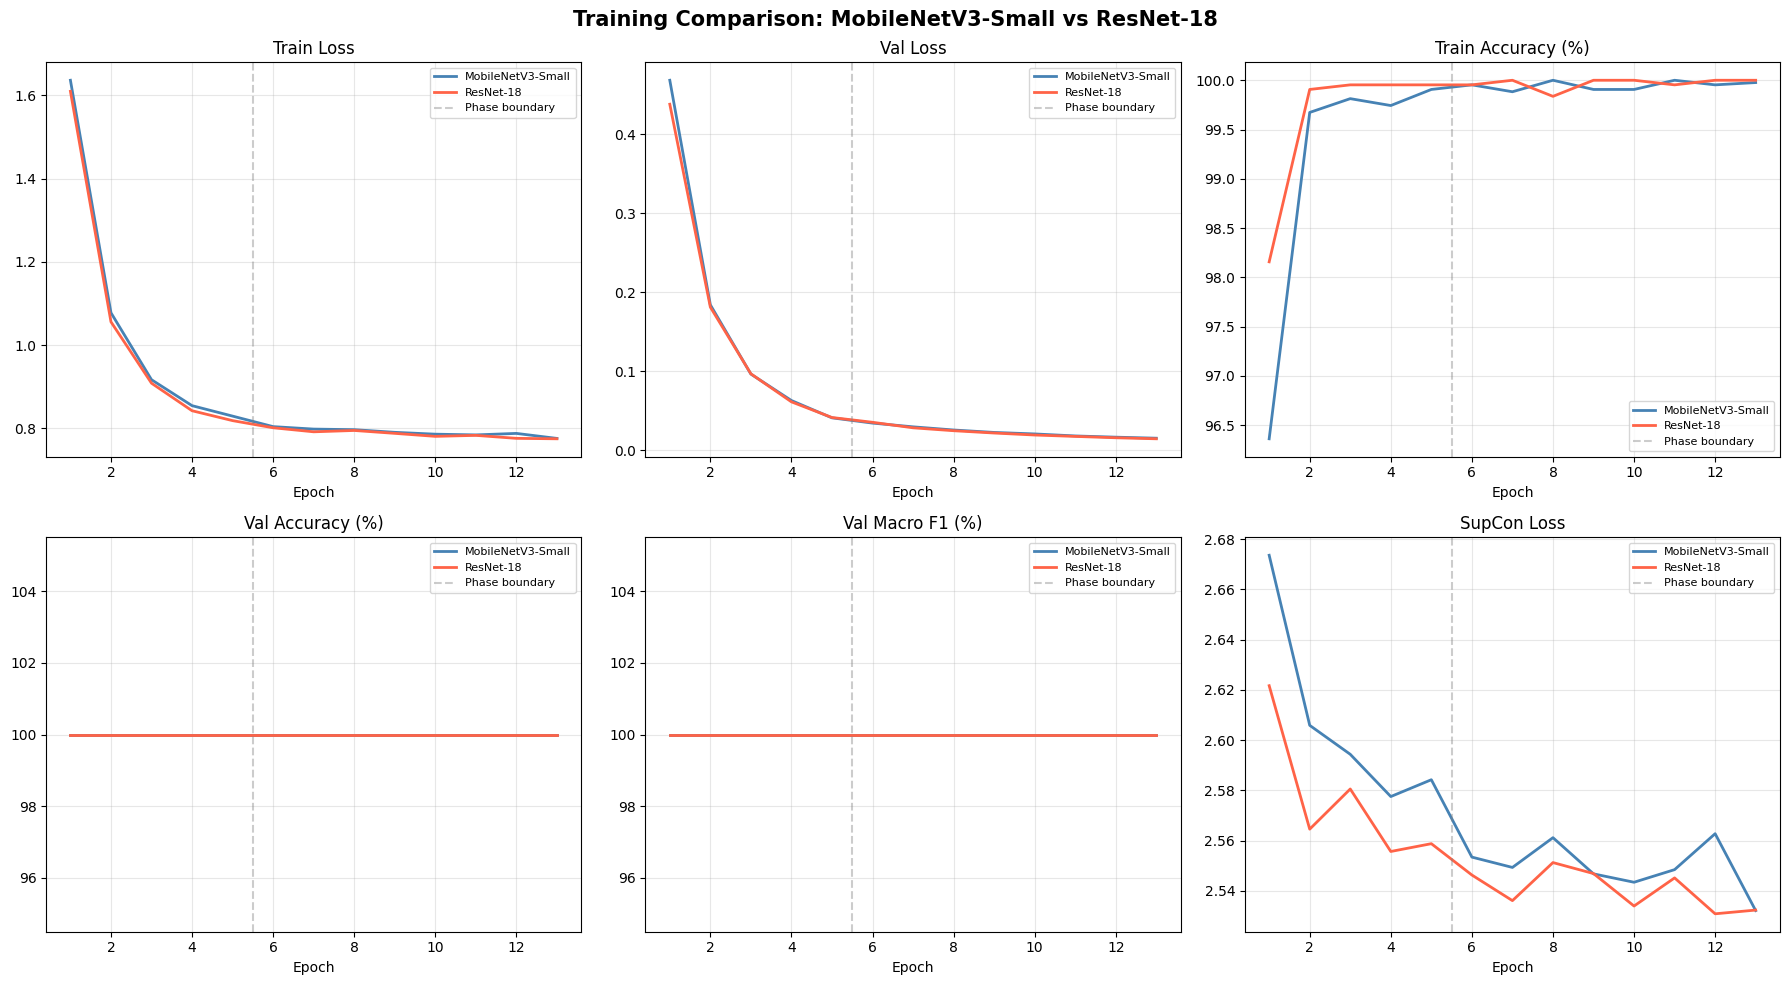

In [ ]:
def plot_comparison_curves(hist_a, hist_b,
                            label_a='MobileNetV3-Small', label_b='ResNet-18'):
    metrics = [
        ('train_loss', 'Train Loss'),
        ('val_loss',   'Val Loss'),
        ('train_acc',  'Train Accuracy (%)'),
        ('val_acc',    'Val Accuracy (%)'),
        ('val_f1',     'Val Macro F1 (%)'),
        ('train_sc',   'SupCon Loss'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training Comparison: MobileNetV3-Small vs ResNet-18',
                 fontsize=15, fontweight='bold')
    wb = EPOCHS_WARMUP + 0.5
    for ax, (key, title) in zip(axes.flat, metrics):
        ep_a = range(1, len(hist_a[key]) + 1)
        ep_b = range(1, len(hist_b[key]) + 1)
        ax.plot(ep_a, hist_a[key], label=label_a, color='steelblue', linewidth=2)
        ax.plot(ep_b, hist_b[key], label=label_b, color='tomato',    linewidth=2)
        ax.axvline(wb, color='gray', linestyle='--', alpha=0.4, label='Phase boundary')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'comparison_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


plot_comparison_curves(hist_mob, hist_res)

## 10. Prototype Bank - Cosine and Multi-Prototype


In [13]:
class PrototypeBank:
    """
    Stores per-class prototype centroids.
    distance_metric='cosine'       -> single prototype per class
    distance_metric='multi_proto'  -> K prototypes per class via K-Means
                                      score = max cosine sim across prototypes
                                      handles multi-modal class distributions
    """

    def __init__(self, embedding_dim, class_to_idx, idx_to_class,
                 confidence_threshold=CONFIDENCE_THRESHOLD,
                 margin_threshold=MARGIN_THRESHOLD,
                 distance_metric='cosine',
                 n_prototypes=3):
        self.embedding_dim        = embedding_dim
        self.class_to_idx         = class_to_idx
        self.idx_to_class         = idx_to_class
        self.confidence_threshold = confidence_threshold
        self.margin_threshold     = margin_threshold
        self.distance_metric      = distance_metric
        self.n_prototypes         = n_prototypes
        self.prototypes           = {}
        self.covariances          = {}
        self.per_class_threshold  = {idx: confidence_threshold for idx in idx_to_class}

    @torch.no_grad()
    def build_from_model(self, model, samples, device, batch_size=64):
        model.eval()
        class_embs = {idx: [] for idx in self.idx_to_class}
        ds     = SimpleDataset(samples, self.class_to_idx, val_transform)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
        for imgs, labels, _ in tqdm(loader, desc='Extracting embeddings'):
            embs = model(imgs.to(device), return_embedding=True).cpu()
            for e, l in zip(embs, labels):
                l = l.item()
                if l in class_embs:
                    class_embs[l].append(e)

        for idx, embs in class_embs.items():
            if not embs:
                continue
            stacked = torch.stack(embs)
            stacked = F.normalize(stacked, p=2, dim=1)
            if self.distance_metric == 'multi_proto':
                self.prototypes[idx] = self._kmeans(stacked, self.n_prototypes)
            else:
                self.prototypes[idx] = F.normalize(stacked.mean(0), p=2, dim=0)

        print(f'Prototypes built for {len(self.prototypes)} classes '
              f'(metric: {self.distance_metric}'
              + (f', K={self.n_prototypes}).' if self.distance_metric == 'multi_proto'
                 else ').'))

    def _kmeans(self, embeddings, k, n_iters=50):
        N, D  = embeddings.shape
        k     = min(k, N)
        idx_init  = torch.randperm(N)[:k]
        centroids = embeddings[idx_init].clone()
        for _ in range(n_iters):
            sims    = torch.mm(embeddings, centroids.T)
            assigns = sims.argmax(dim=1)
            new_centroids = torch.zeros_like(centroids)
            for j in range(k):
                members = embeddings[assigns == j]
                if len(members) == 0:
                    new_centroids[j] = centroids[j]
                else:
                    new_centroids[j] = F.normalize(members.mean(0), p=2, dim=0)
            if torch.allclose(centroids, new_centroids, atol=1e-5):
                break
            centroids = new_centroids
        return centroids

    def _cosine_score(self, emb, idx):
        return torch.dot(
            F.normalize(emb.cpu(), p=2, dim=0),
            self.prototypes[idx].cpu()
        ).item()

    def _multi_proto_score(self, emb, idx):
        protos = self.prototypes[idx].cpu()
        normed = F.normalize(emb.cpu(), p=2, dim=0)
        sims   = torch.mv(protos, normed)
        return sims.max().item()

    def _score(self, emb, idx):
        if self.distance_metric == 'multi_proto':
            return self._multi_proto_score(emb, idx)
        return self._cosine_score(emb, idx)

    def predict(self, embedding):
        if not self.prototypes:
            return 'unknown', 0.0, []
        scores   = {idx: self._score(embedding, idx) for idx in self.prototypes}
        sorted_s = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        top_idx, s1 = sorted_s[0]
        s2     = sorted_s[1][1] if len(sorted_s) > 1 else 0.0
        top3   = [(self.idx_to_class[i], round(s, 4)) for i, s in sorted_s[:3]]
        thresh = self.per_class_threshold.get(top_idx, self.confidence_threshold)
        if s1 < thresh:
            return 'unknown', round(s1, 4), top3
        if (s1 - s2) < self.margin_threshold:
            return 'ambiguous', round(s1, 4), top3
        return self.idx_to_class[top_idx], round(s1, 4), top3

    def calibrate_thresholds(self, model, val_samples, device,
                              target_recall=0.95, batch_size=64):
        model.eval()
        class_scores = {idx: [] for idx in self.idx_to_class}
        ds     = SimpleDataset(val_samples, self.class_to_idx, val_transform)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        with torch.no_grad():
            for imgs, labels, _ in loader:
                embs = model(imgs.to(device), return_embedding=True).cpu()
                for e, l in zip(embs, labels):
                    l = l.item()
                    if l in self.prototypes:
                        class_scores[l].append(self._score(e, l))
        rows = []
        for idx, scores in class_scores.items():
            if not scores:
                continue
            thresh = float(np.percentile(scores, (1 - target_recall) * 100))
            thresh = max(0.10, min(thresh, 0.98))
            self.per_class_threshold[idx] = thresh
            rows.append([self.idx_to_class[idx],
                         f'{np.mean(scores):.4f}',
                         f'{np.std(scores):.4f}',
                         f'{thresh:.4f}'])
        print(f'Calibrated thresholds [{self.distance_metric}]:')
        print(tabulate(rows,
                       headers=['Class', 'Mean Score', 'Std Score', 'Threshold'],
                       tablefmt='fancy_grid'))

    def add_new_class(self, class_name, pil_images, model, device):
        if class_name in self.class_to_idx:
            print(f'Class {class_name} already exists.')
            return
        new_idx = max(self.class_to_idx.values()) + 1
        self.class_to_idx[class_name] = new_idx
        self.idx_to_class[new_idx]    = class_name
        model.eval()
        embs = []
        with torch.no_grad():
            for img in pil_images:
                t = val_transform(img).unsqueeze(0).to(device)
                embs.append(model(t, return_embedding=True).squeeze(0).cpu())
        stacked = torch.stack(embs)
        stacked = F.normalize(stacked, p=2, dim=1)
        if self.distance_metric == 'multi_proto':
            self.prototypes[new_idx] = self._kmeans(stacked, self.n_prototypes)
        else:
            self.prototypes[new_idx] = F.normalize(stacked.mean(0), p=2, dim=0)
        self.per_class_threshold[new_idx] = self.confidence_threshold
        print(f'New class "{class_name}" registered ({len(embs)} images).')
        print(f'Known classes: {list(self.class_to_idx.keys())}')

    def save(self, path):
        torch.save(dict(
            prototypes=self.prototypes,
            covariances=self.covariances,
            class_to_idx=self.class_to_idx,
            idx_to_class=self.idx_to_class,
            per_class_threshold=self.per_class_threshold,
            confidence_threshold=self.confidence_threshold,
            margin_threshold=self.margin_threshold,
            embedding_dim=self.embedding_dim,
            distance_metric=self.distance_metric,
            n_prototypes=self.n_prototypes,
        ), path)
        print(f'Bank saved: {path}')

    @classmethod
    def load(cls, path):
        d    = torch.load(path, map_location='cpu')
        bank = cls(
            embedding_dim=d['embedding_dim'],
            class_to_idx=d['class_to_idx'],
            idx_to_class=d['idx_to_class'],
            confidence_threshold=d['confidence_threshold'],
            margin_threshold=d['margin_threshold'],
            distance_metric=d['distance_metric'],
            n_prototypes=d.get('n_prototypes', 3),
        )
        bank.prototypes          = d['prototypes']
        bank.covariances         = d.get('covariances', {})
        bank.per_class_threshold = d['per_class_threshold']
        print(f'Bank loaded: {path}')
        return bank

print('PrototypeBank ready.')


PrototypeBank ready.


## 11. Build All Four Prototype Banks

In [14]:
CKPT_MOB = os.path.join(CHECKPOINT_DIR, 'best_mobilenet.pth')
CKPT_RES = os.path.join(CHECKPOINT_DIR, 'best_resnet18.pth')

def reload_model(backbone_name, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    m = PrototypeRecognizer(
        num_classes=ckpt['num_classes'],
        backbone_name=backbone_name,
        embedding_dim=ckpt['embedding_dim'],
        dropout=DROPOUT,
        pretrained=False
    ).to(DEVICE)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    print(f'  Loaded {backbone_name:12s} | epoch {ckpt["epoch"]:02d} '
          f'| ValF1: {ckpt["metrics"]["f1"]:.2f}%')
    return m

print('Loading backbones from Drive ...')
model_mobilenet = reload_model('mobilenet', CKPT_MOB)
model_resnet    = reload_model('resnet18',  CKPT_RES)
print('Both backbones loaded.\n')

Loading backbones from Drive ...
  Loaded mobilenet    | epoch 06 | ValF1: 100.00%
  Loaded resnet18     | epoch 06 | ValF1: 100.00%
Both backbones loaded.



In [15]:

all_train_val = train_samples + val_samples


def build_and_save_bank(model, backbone_name, metric, n_prototypes=3):
    print(f'--- {backbone_name} + {metric} ---')
    bank = PrototypeBank(
        embedding_dim=EMBEDDING_DIM,
        class_to_idx=copy.deepcopy(CLASS_TO_IDX),
        idx_to_class=copy.deepcopy(IDX_TO_CLASS),
        distance_metric=metric,
        n_prototypes=n_prototypes,
    )
    bank.build_from_model(model, all_train_val, DEVICE)
    bank.calibrate_thresholds(model, val_samples, DEVICE, target_recall=0.95)
    path = os.path.join(CHECKPOINT_DIR, f'bank_{backbone_name}_{metric}.pth')
    bank.save(path)
    print()
    return bank, path

bank_mob_cos, path_mob_cos = build_and_save_bank(model_mobilenet, 'mobilenet', 'cosine')
bank_mob_mpr, path_mob_mpr = build_and_save_bank(model_mobilenet, 'mobilenet', 'multi_proto', n_prototypes=3)
bank_res_cos, path_res_cos = build_and_save_bank(model_resnet,    'resnet18',  'cosine')
bank_res_mpr, path_res_mpr = build_and_save_bank(model_resnet,    'resnet18',  'multi_proto', n_prototypes=3)


--- mobilenet + cosine ---


Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Prototypes built for 5 classes (metric: cosine).
Calibrated thresholds [cosine]:
╒═════════╤══════════════╤═════════════╤═════════════╕
│ Class   │   Mean Score │   Std Score │   Threshold │
╞═════════╪══════════════╪═════════════╪═════════════╡
│ carpet  │       0.9994 │      0.0007 │      0.98   │
├─────────┼──────────────┼─────────────┼─────────────┤
│ grid    │       0.99   │      0.0083 │      0.9749 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ leather │       0.9997 │      0.0003 │      0.98   │
├─────────┼──────────────┼─────────────┼─────────────┤
│ tile    │       0.9988 │      0.0011 │      0.98   │
├─────────┼──────────────┼─────────────┼─────────────┤
│ wood    │       0.9945 │      0.0125 │      0.98   │
╘═════════╧══════════════╧═════════════╧═════════════╛
Bank saved: /content/drive/MyDrive/C_checkpoints/bank_mobilenet_cosine.pth

--- mobilenet + multi_proto ---


Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Prototypes built for 5 classes (metric: multi_proto, K=3).
Calibrated thresholds [multi_proto]:
╒═════════╤══════════════╤═════════════╤═════════════╕
│ Class   │   Mean Score │   Std Score │   Threshold │
╞═════════╪══════════════╪═════════════╪═════════════╡
│ carpet  │       0.9997 │      0.0003 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ grid    │       0.9966 │      0.003  │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ leather │       0.9998 │      0.0002 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ tile    │       0.9994 │      0.0004 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ wood    │       0.9987 │      0.0034 │        0.98 │
╘═════════╧══════════════╧═════════════╧═════════════╛
Bank saved: /content/drive/MyDrive/C_checkpoints/bank_mobilenet_multi_proto.pth

--- resnet18 + cosine ---


Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Prototypes built for 5 classes (metric: cosine).
Calibrated thresholds [cosine]:
╒═════════╤══════════════╤═════════════╤═════════════╕
│ Class   │   Mean Score │   Std Score │   Threshold │
╞═════════╪══════════════╪═════════════╪═════════════╡
│ carpet  │       0.9997 │      0.0002 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ grid    │       0.999  │      0.0007 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ leather │       0.9988 │      0.0012 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ tile    │       0.9998 │      0.0002 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ wood    │       0.9974 │      0.0033 │        0.98 │
╘═════════╧══════════════╧═════════════╧═════════════╛
Bank saved: /content/drive/MyDrive/C_checkpoints/bank_resnet18_cosine.pth

--- resnet18 + multi_proto ---


Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Prototypes built for 5 classes (metric: multi_proto, K=3).
Calibrated thresholds [multi_proto]:
╒═════════╤══════════════╤═════════════╤═════════════╕
│ Class   │   Mean Score │   Std Score │   Threshold │
╞═════════╪══════════════╪═════════════╪═════════════╡
│ carpet  │       0.9999 │      0.0001 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ grid    │       0.9994 │      0.0005 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ leather │       0.9996 │      0.0003 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ tile    │       0.9999 │      0.0001 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ wood    │       0.9994 │      0.0007 │        0.98 │
╘═════════╧══════════════╧═════════════╧═════════════╛
Bank saved: /content/drive/MyDrive/C_checkpoints/bank_resnet18_multi_proto.pth



## 12. Inference and Evaluation Utilities

In [16]:
@torch.no_grad()
def predict_batch(model, bank, loader, device):
    model.eval()
    preds, confs, top3s, gts, paths_out = [], [], [], [], []
    for imgs, labels, paths in tqdm(loader, leave=False):
        embs = model(imgs.to(device), return_embedding=True)
        for e, l, p in zip(embs, labels, paths):
            pred, conf, top3 = bank.predict(e)
            preds.append(pred)
            confs.append(conf)
            top3s.append(top3)
            gts.append(l.item())
            paths_out.append(p)
    return preds, confs, top3s, gts, paths_out


@torch.no_grad()
def predict_single(model, bank, pil_img, device):
    model.eval()
    t   = val_transform(pil_img).unsqueeze(0).to(device)
    emb = model(t, return_embedding=True).squeeze(0)
    return bank.predict(emb)


def evaluate_system(model, bank, test_samples, label='', device=DEVICE):
    ds     = SimpleDataset(test_samples, CLASS_TO_IDX, val_transform)
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    preds, confs, top3s, gts, _ = predict_batch(model, bank, loader, device)
    gt_names = [IDX_TO_CLASS.get(g, 'unknown') for g in gts]

    accepted  = [(p, g) for p, g in zip(preds, gt_names)
                 if p not in ('unknown','ambiguous')]
    acc_preds = [x[0] for x in accepted]
    acc_gt    = [x[1] for x in accepted]

    if acc_preds:
        acc    = accuracy_score(acc_gt, acc_preds) * 100
        f1_mac = f1_score(acc_gt, acc_preds, average='macro')    * 100
        f1_wt  = f1_score(acc_gt, acc_preds, average='weighted') * 100
        prec   = precision_score(acc_gt, acc_preds, average='macro') * 100
        rec    = recall_score(acc_gt, acc_preds, average='macro')    * 100
    else:
        acc = f1_mac = f1_wt = prec = rec = 0.0

    rej_n = sum(1 for p in preds if p in ('unknown','ambiguous'))
    return dict(label=label, acc=acc, f1_mac=f1_mac, f1_wt=f1_wt,
                prec=prec, rec=rec, total=len(preds),
                accepted=len(accepted), rejected=rej_n,
                preds=preds, confs=confs, gt_names=gt_names,
                acc_preds=acc_preds, acc_gt=acc_gt)


def measure_speed(model, bank, device, n=100):
    model.eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        for _ in range(10):
            model(dummy, return_embedding=True)
    times = []
    with torch.no_grad():
        for _ in range(n):
            t0  = time.perf_counter()
            emb = model(dummy, return_embedding=True).squeeze(0)
            bank.predict(emb)
            times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), 1000.0 / np.mean(times)


print('Inference utilities ready.')

Inference utilities ready.


## 13. Evaluate All Four Combinations

In [17]:
bank_mob_cos = PrototypeBank.load(os.path.join(CHECKPOINT_DIR, 'bank_mobilenet_cosine.pth'))
bank_mob_mpr = PrototypeBank.load(os.path.join(CHECKPOINT_DIR, 'bank_mobilenet_multi_proto.pth'))
bank_res_cos = PrototypeBank.load(os.path.join(CHECKPOINT_DIR, 'bank_resnet18_cosine.pth'))
bank_res_mpr = PrototypeBank.load(os.path.join(CHECKPOINT_DIR, 'bank_resnet18_multi_proto.pth'))

for name, bank in [('bank_mob_mpr', bank_mob_mpr), ('bank_res_mpr', bank_res_mpr)]:
    idx = list(bank.prototypes.keys())[0]
    print(f'{name}: n_prototypes={bank.n_prototypes}  proto shape={bank.prototypes[idx].shape}')


Bank loaded: /content/drive/MyDrive/C_checkpoints/bank_mobilenet_cosine.pth
Bank loaded: /content/drive/MyDrive/C_checkpoints/bank_mobilenet_multi_proto.pth
Bank loaded: /content/drive/MyDrive/C_checkpoints/bank_resnet18_cosine.pth
Bank loaded: /content/drive/MyDrive/C_checkpoints/bank_resnet18_multi_proto.pth
bank_mob_mpr: n_prototypes=3  proto shape=torch.Size([3, 128])
bank_res_mpr: n_prototypes=3  proto shape=torch.Size([3, 128])


In [18]:
print('Calibrating multi-prototype banks...')
bank_mob_mpr.calibrate_thresholds(model_mobilenet, val_samples, DEVICE, target_recall=0.95)
bank_res_mpr.calibrate_thresholds(model_resnet,    val_samples, DEVICE, target_recall=0.95)
print('Done.')


Calibrating multi-prototype banks...
Calibrated thresholds [multi_proto]:
╒═════════╤══════════════╤═════════════╤═════════════╕
│ Class   │   Mean Score │   Std Score │   Threshold │
╞═════════╪══════════════╪═════════════╪═════════════╡
│ carpet  │       0.9997 │      0.0003 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ grid    │       0.9966 │      0.003  │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ leather │       0.9998 │      0.0002 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ tile    │       0.9994 │      0.0004 │        0.98 │
├─────────┼──────────────┼─────────────┼─────────────┤
│ wood    │       0.9987 │      0.0034 │        0.98 │
╘═════════╧══════════════╧═════════════╧═════════════╛
Calibrated thresholds [multi_proto]:
╒═════════╤══════════════╤═════════════╤═════════════╕
│ Class   │   Mean Score │   Std Score │   Threshold │
╞═════════╪══════════════╪═════════════╪═════════════╡
│ carpet 

In [19]:
test_samples = collect_test_images(MVTEC_ROOT, KNOWN_CLASSES)

combos = [
    (model_mobilenet, bank_mob_cos, 'MobileNet + Cosine'),
    (model_mobilenet, bank_mob_mpr, 'MobileNet + Multi-Prototype'),
    (model_resnet,    bank_res_cos, 'ResNet-18 + Cosine'),
    (model_resnet,    bank_res_mpr, 'ResNet-18 + Multi-Prototype'),
]

results = []
for model, bank, label in combos:
    print(f'Evaluating: {label}')
    r           = evaluate_system(model, bank, test_samples, label)
    ms, fps     = measure_speed(model, bank, DEVICE)
    r['speed_ms'] = ms
    r['fps']      = fps
    results.append(r)
    print(f'  Acc: {r["acc"]:.2f}%  F1: {r["f1_mac"]:.2f}%  '
          f'Rejected: {r["rejected"]}/{r["total"]}  Speed: {ms:.2f}ms\n')


Good test images: 133
Evaluating: MobileNet + Cosine


  0%|          | 0/5 [00:00<?, ?it/s]

  Acc: 100.00%  F1: 100.00%  Rejected: 4/133  Speed: 6.11ms

Evaluating: MobileNet + Multi-Prototype


  0%|          | 0/5 [00:00<?, ?it/s]

  Acc: 100.00%  F1: 100.00%  Rejected: 0/133  Speed: 6.10ms

Evaluating: ResNet-18 + Cosine


  0%|          | 0/5 [00:00<?, ?it/s]

  Acc: 100.00%  F1: 100.00%  Rejected: 0/133  Speed: 3.48ms

Evaluating: ResNet-18 + Multi-Prototype


  0%|          | 0/5 [00:00<?, ?it/s]

  Acc: 100.00%  F1: 100.00%  Rejected: 0/133  Speed: 3.36ms



## 14. Master Comparison Table

In [20]:
mob_size = sum(p.numel()*p.element_size() for p in model_mobilenet.parameters())/1e6
res_size = sum(p.numel()*p.element_size() for p in model_resnet.parameters())/1e6
size_map = {
    'MobileNet + Cosine':          mob_size,
    'MobileNet + Multi-Prototype': mob_size,
    'ResNet-18 + Cosine':          res_size,
    'ResNet-18 + Multi-Prototype': res_size,
}

comp_rows = []
for r in results:
    comp_rows.append([
        r['label'],
        f'{r["acc"]:.2f}%',
        f'{r["f1_mac"]:.2f}%',
        f'{r["rejected"]}/{r["total"]}',
        f'{r["speed_ms"]:.2f} ms',
        f'{size_map[r["label"]]:.1f} MB',
    ])

print('=' * 70)
print('MASTER COMPARISON TABLE')
print('=' * 70)
print(tabulate(
    comp_rows,
    headers=['Configuration', 'Accuracy', 'Macro F1', 'Rejected', 'Speed', 'Size'],
    tablefmt='fancy_grid'
))

best_acc = max(results, key=lambda r: r['acc'])
best_f1  = max(results, key=lambda r: r['f1_mac'])
best_spd = min(results, key=lambda r: r['speed_ms'])
print(tabulate([
    ['Best Accuracy',     best_acc['label'], f'{best_acc["acc"]:.2f}%'],
    ['Best Macro F1',     best_f1['label'],  f'{best_f1["f1_mac"]:.2f}%'],
    ['Fastest Inference', best_spd['label'], f'{best_spd["speed_ms"]:.2f} ms'],
], headers=['Metric','Configuration','Value'], tablefmt='fancy_grid'))


MASTER COMPARISON TABLE
╒═════════════════════════════╤════════════╤════════════╤════════════╤═════════╤═════════╕
│ Configuration               │ Accuracy   │ Macro F1   │ Rejected   │ Speed   │ Size    │
╞═════════════════════════════╪════════════╪════════════╪════════════╪═════════╪═════════╡
│ MobileNet + Cosine          │ 100.00%    │ 100.00%    │ 4/133      │ 6.11 ms │ 5.2 MB  │
├─────────────────────────────┼────────────┼────────────┼────────────┼─────────┼─────────┤
│ MobileNet + Multi-Prototype │ 100.00%    │ 100.00%    │ 0/133      │ 6.10 ms │ 5.2 MB  │
├─────────────────────────────┼────────────┼────────────┼────────────┼─────────┼─────────┤
│ ResNet-18 + Cosine          │ 100.00%    │ 100.00%    │ 0/133      │ 3.48 ms │ 46.0 MB │
├─────────────────────────────┼────────────┼────────────┼────────────┼─────────┼─────────┤
│ ResNet-18 + Multi-Prototype │ 100.00%    │ 100.00%    │ 0/133      │ 3.36 ms │ 46.0 MB │
╘═════════════════════════════╧════════════╧════════════╧═════════

## 15. Confusion Matrices - All Configurations

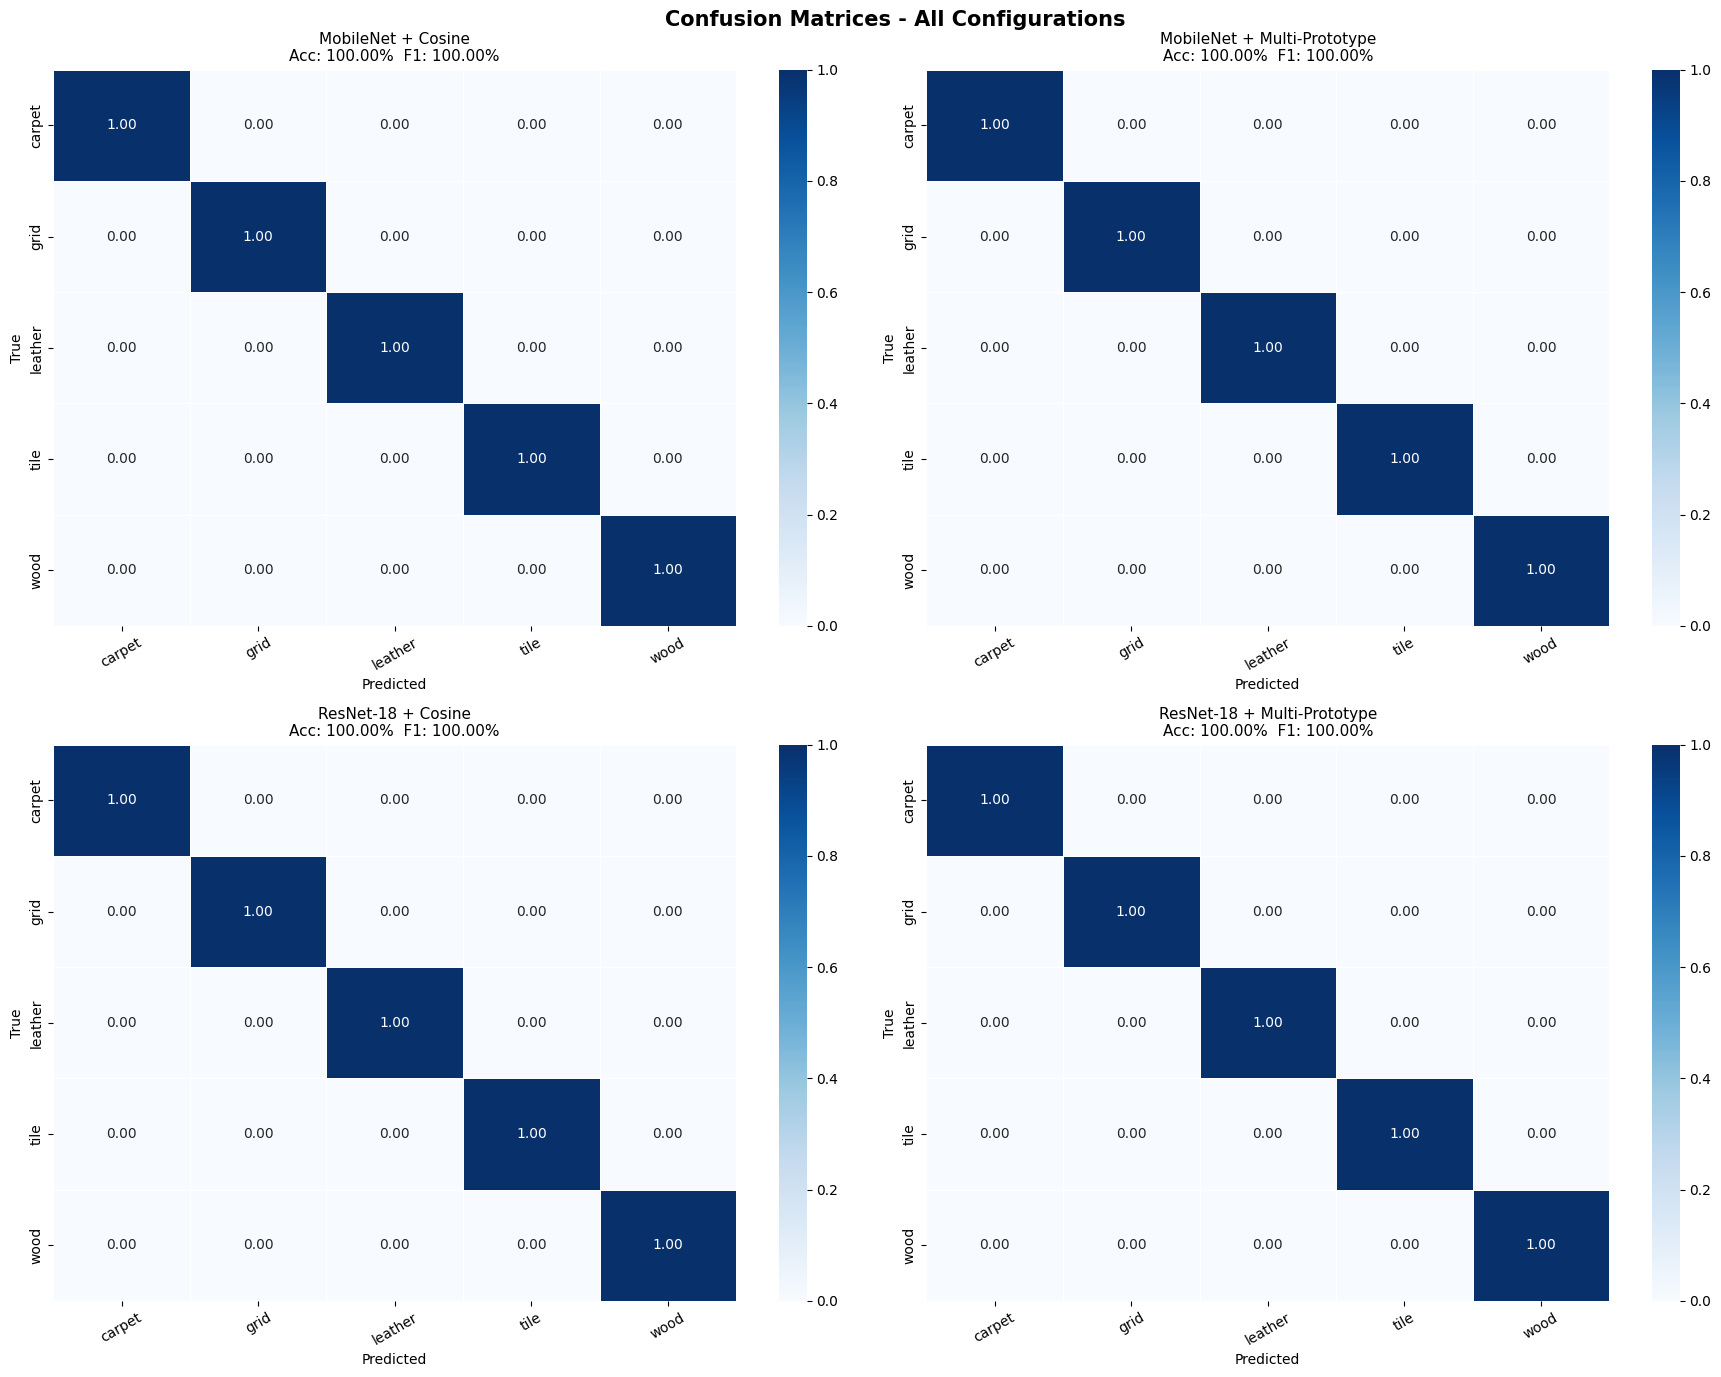

In [21]:
def plot_four_confusion_matrices(results, class_names):
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Confusion Matrices - All Configurations',
                 fontsize=15, fontweight='bold')
    for ax, r in zip(axes.flat, results):
        if not r['acc_preds']:
            ax.set_title(r['label'])
            continue
        cm      = confusion_matrix(r['acc_gt'], r['acc_preds'], labels=class_names)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True).clip(min=1)
        sns.heatmap(cm_norm, annot=True, fmt='.2f',
                    xticklabels=class_names, yticklabels=class_names,
                    cmap='Blues', ax=ax, linewidths=0.5, vmin=0, vmax=1)
        ax.set_title(
            f'{r["label"]}\nAcc: {r["acc"]:.2f}%  F1: {r["f1_mac"]:.2f}%',
            fontsize=11
        )
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'all_confusion_matrices.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


plot_four_confusion_matrices(results, sorted(KNOWN_CLASSES))

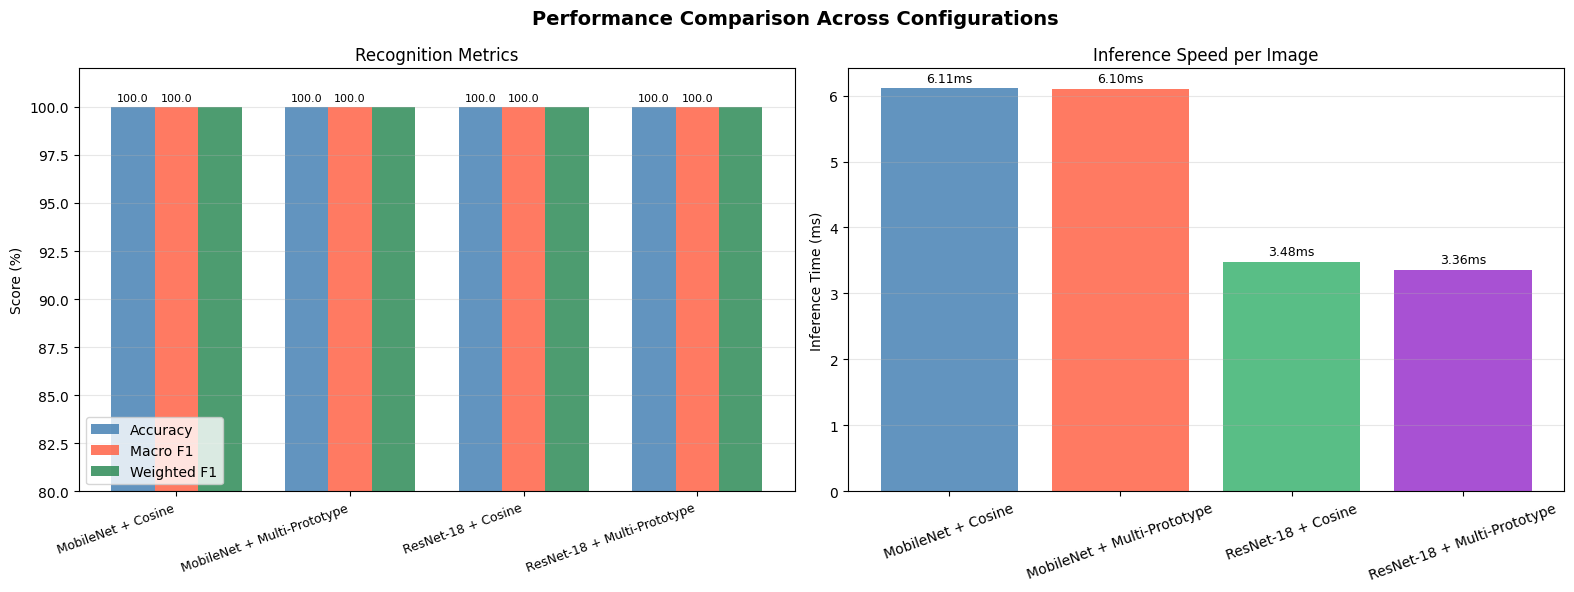

In [22]:
def plot_metric_bars(results):
    labels  = [r['label']    for r in results]
    accs    = [r['acc']      for r in results]
    f1_macs = [r['f1_mac']   for r in results]
    f1_wts  = [r['f1_wt']    for r in results]
    speeds  = [r['speed_ms'] for r in results]
    x       = np.arange(len(labels))
    width   = 0.25
    colors  = ['steelblue','tomato','mediumseagreen','darkorchid']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Performance Comparison Across Configurations',
                 fontsize=14, fontweight='bold')

    ax = axes[0]
    ax.bar(x - width, accs,    width, label='Accuracy',    color='steelblue', alpha=0.85)
    ax.bar(x,         f1_macs, width, label='Macro F1',    color='tomato',    alpha=0.85)
    ax.bar(x + width, f1_wts,  width, label='Weighted F1', color='seagreen',  alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Score (%)')
    ax.set_ylim([80, 102])
    ax.set_title('Recognition Metrics')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    for i, (a, f) in enumerate(zip(accs, f1_macs)):
        ax.text(i - width, a + 0.3, f'{a:.1f}', ha='center', fontsize=8)
        ax.text(i,         f + 0.3, f'{f:.1f}', ha='center', fontsize=8)

    ax2 = axes[1]
    bars = ax2.bar(labels, speeds, color=colors, alpha=0.85)
    ax2.set_ylabel('Inference Time (ms)')
    ax2.set_title('Inference Speed per Image')
    ax2.tick_params(axis='x', rotation=20)
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, spd in zip(bars, speeds):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1, f'{spd:.2f}ms',
                 ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'metric_comparison_bars.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


plot_metric_bars(results)


=== Per-class confidence summary (known test set) ===
╒═════════════════════════════╤═════════╤═════╤═════════════╤════════════╤═══════════╤═════════╤════════════╕
│ Config                      │ Class   │   N │   Mean conf │   Std conf │   Correct │   Wrong │   Rejected │
╞═════════════════════════════╪═════════╪═════╪═════════════╪════════════╪═══════════╪═════════╪════════════╡
│ MobileNet + Cosine          │ carpet  │  28 │      0.9973 │     0.0032 │        28 │       0 │          0 │
├─────────────────────────────┼─────────┼─────┼─────────────┼────────────┼───────────┼─────────┼────────────┤
│ MobileNet + Cosine          │ grid    │  21 │      0.9909 │     0.009  │        19 │       0 │          2 │
├─────────────────────────────┼─────────┼─────┼─────────────┼────────────┼───────────┼─────────┼────────────┤
│ MobileNet + Cosine          │ leather │  32 │      0.999  │     0.0007 │        32 │       0 │          0 │
├─────────────────────────────┼─────────┼─────┼─────────────┼────

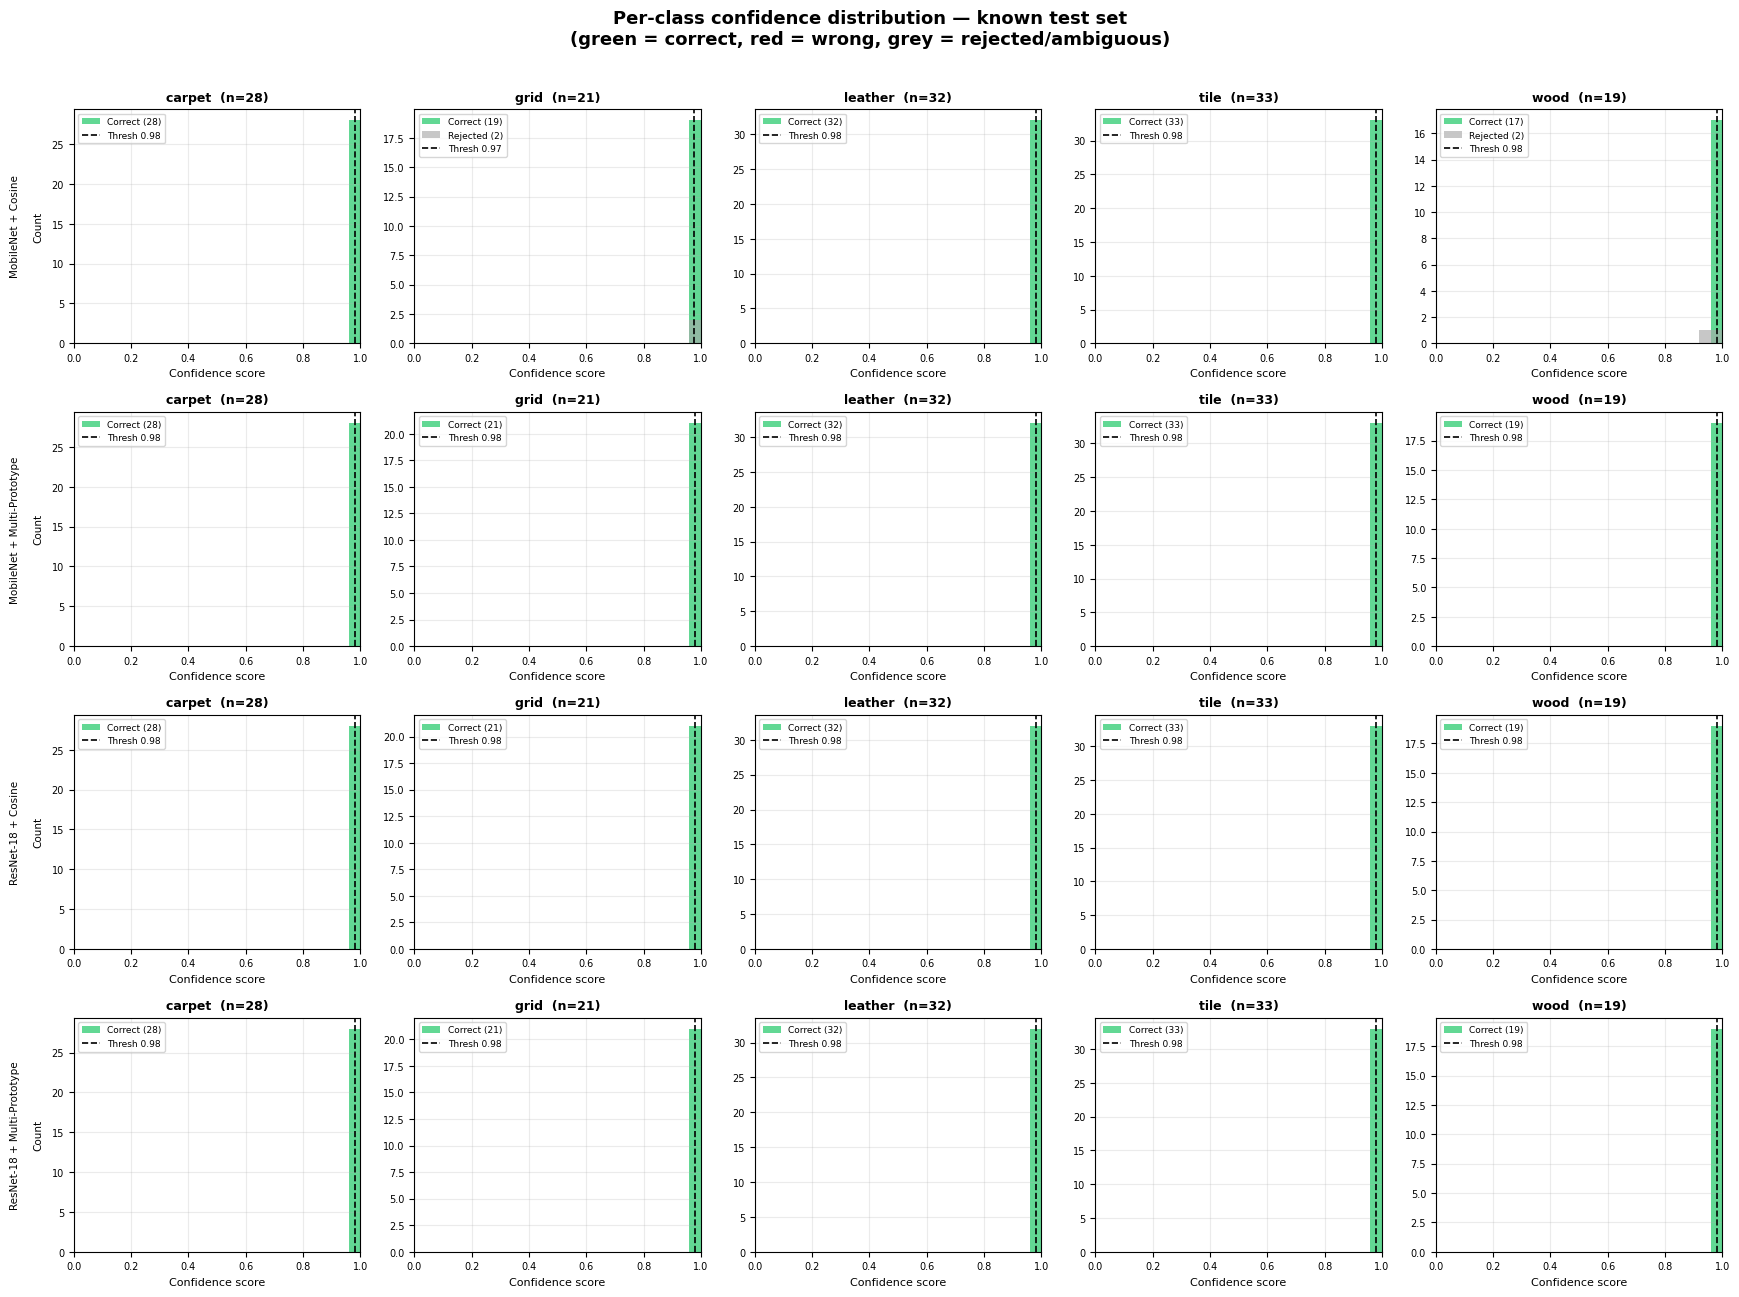

Saved → /content/drive/MyDrive/C_checkpoints/per_class_confidence.png


In [23]:
#  Per-class confidence distribution on the known test set

def plot_per_class_confidence(results, known_classes, checkpoint_dir):
    """
    For each combo (row) × each known class (column):
    plots a histogram of confidence scores, coloured by correct/wrong/rejected.
    """
    cls_sorted = sorted(known_classes)
    n_combos   = len(results)
    n_classes  = len(cls_sorted)

    fig, axes = plt.subplots(
        n_combos, n_classes,
        figsize=(3.5 * n_classes, 3.2 * n_combos),
        squeeze=False
    )
    fig.suptitle(
        'Per-class confidence distribution — known test set\n'
        '(green = correct, red = wrong, grey = rejected/ambiguous)',
        fontsize=13, fontweight='bold', y=1.01
    )

    for row, r in enumerate(results):
        # Zip every sample's (gt, pred, conf) together
        sample_data = list(zip(r['gt_names'], r['preds'], r['confs']))

        for col, cls in enumerate(cls_sorted):
            ax = axes[row][col]

            # Only samples whose ground-truth is this class
            cls_samples = [(pred, conf)
                           for gt, pred, conf in sample_data
                           if gt == cls]

            correct   = [c for p, c in cls_samples if p == cls]
            wrong     = [c for p, c in cls_samples
                         if p not in (cls, 'unknown', 'ambiguous')]
            rejected  = [c for p, c in cls_samples
                         if p in ('unknown', 'ambiguous')]

            bins = np.linspace(0, 1, 26)

            if correct:
                ax.hist(correct,  bins=bins, color='#2ecc71', alpha=0.75,
                        label=f'Correct ({len(correct)})')
            if wrong:
                ax.hist(wrong,    bins=bins, color='#e74c3c', alpha=0.75,
                        label=f'Wrong ({len(wrong)})')
            if rejected:
                ax.hist(rejected, bins=bins, color='#aaaaaa', alpha=0.65,
                        label=f'Rejected ({len(rejected)})')

            # Per-class threshold line
            cls_idx  = list(r['preds'])  # reuse r to find bank threshold
            bank_key = [k for k in CLASS_TO_IDX if k == cls]
            if bank_key:
                idx    = CLASS_TO_IDX[bank_key[0]]
                # We stored the bank in combos; look it up by label
                combo  = next((b for _, b, lbl in combos if lbl == r['label']), None)
                if combo and idx in combo.per_class_threshold:
                    thresh = combo.per_class_threshold[idx]
                    ax.axvline(thresh, color='black', linewidth=1.2,
                               linestyle='--', label=f'Thresh {thresh:.2f}')

            # Styling
            n_total = len(cls_samples)
            ax.set_title(
                f'{cls}  (n={n_total})',
                fontsize=9, fontweight='bold'
            )
            ax.set_xlabel('Confidence score', fontsize=8)
            ax.set_ylabel('Count' if col == 0 else '', fontsize=8)
            ax.set_xlim(0, 1)
            ax.tick_params(labelsize=7)
            ax.legend(fontsize=6.5, loc='upper left')
            ax.grid(True, alpha=0.25)

            # Row label on leftmost column
            if col == 0:
                ax.set_ylabel(
                    f'{r["label"]}\n\nCount', fontsize=7.5, labelpad=6
                )

    plt.tight_layout()
    save_path = os.path.join(checkpoint_dir, 'per_class_confidence.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


#  Numeric summary table

def per_class_confidence_table(results, known_classes):
    """
    Prints mean ± std confidence per class per combo,
    broken down by correct / wrong / rejected.
    """
    cls_sorted = sorted(known_classes)
    header = ['Config', 'Class', 'N', 'Mean conf', 'Std conf',
              'Correct', 'Wrong', 'Rejected']
    rows = []

    for r in results:
        sample_data = list(zip(r['gt_names'], r['preds'], r['confs']))
        for cls in cls_sorted:
            cls_samples = [(pred, conf)
                           for gt, pred, conf in sample_data
                           if gt == cls]
            if not cls_samples:
                continue
            confs_all = [c for _, c in cls_samples]
            correct   = sum(1 for p, _ in cls_samples if p == cls)
            wrong     = sum(1 for p, _ in cls_samples
                            if p not in (cls, 'unknown', 'ambiguous'))
            rejected  = sum(1 for p, _ in cls_samples
                            if p in ('unknown', 'ambiguous'))
            rows.append([
                r['label'], cls, len(cls_samples),
                f'{np.mean(confs_all):.4f}',
                f'{np.std(confs_all):.4f}',
                correct, wrong, rejected
            ])

    print('\n=== Per-class confidence summary (known test set) ===')
    print(tabulate(rows, headers=header, tablefmt='fancy_grid'))


# ── Run both ──────────────────────────────────────────────────────────────────
per_class_confidence_table(results, KNOWN_CLASSES)
plot_per_class_confidence(results, KNOWN_CLASSES, CHECKPOINT_DIR)

## 16. Unknown-Class Rejection Test

Scanning /content/mvtec for unknown classes ...
  None found in MVTEC_ROOT.
Scanning EXTERNAL_IMAGES_DIR: /content/drive/MyDrive/Colab Notebooks/ICT304/dataset ...
  [bottle] 20 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/bottle/test/good)
  [cable] 58 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/cable/test/good)
  [capsule] 23 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/capsule/test/good)
  [hazelnut] 40 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/hazelnut/test/good)
  [metal_nut] 22 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/metal_nut/test/good)
  [pill] 26 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/pill/test/good)
  [results] 1 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/results)
  [screw] 41 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/screw/test/good)
  [toothbrush] 12 images  (/content/drive/MyDrive/Colab Notebooks/ICT304/dataset/

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]


=== Unknown-Class Rejection Comparison ===
╒═════════════════════════════╤═════════╤════════════╤════════╤════════╕
│ Configuration               │   Total │   Rejected │ UCRR   │ FAR    │
╞═════════════════════════════╪═════════╪════════════╪════════╪════════╡
│ MobileNet + Cosine          │     335 │        313 │ 93.43% │ 6.57%  │
├─────────────────────────────┼─────────┼────────────┼────────┼────────┤
│ MobileNet + Multi-Prototype │     335 │        284 │ 84.78% │ 15.22% │
├─────────────────────────────┼─────────┼────────────┼────────┼────────┤
│ ResNet-18 + Cosine          │     335 │        317 │ 94.63% │ 5.37%  │
├─────────────────────────────┼─────────┼────────────┼────────┼────────┤
│ ResNet-18 + Multi-Prototype │     335 │        316 │ 94.33% │ 5.67%  │
╘═════════════════════════════╧═════════╧════════════╧════════╧════════╛


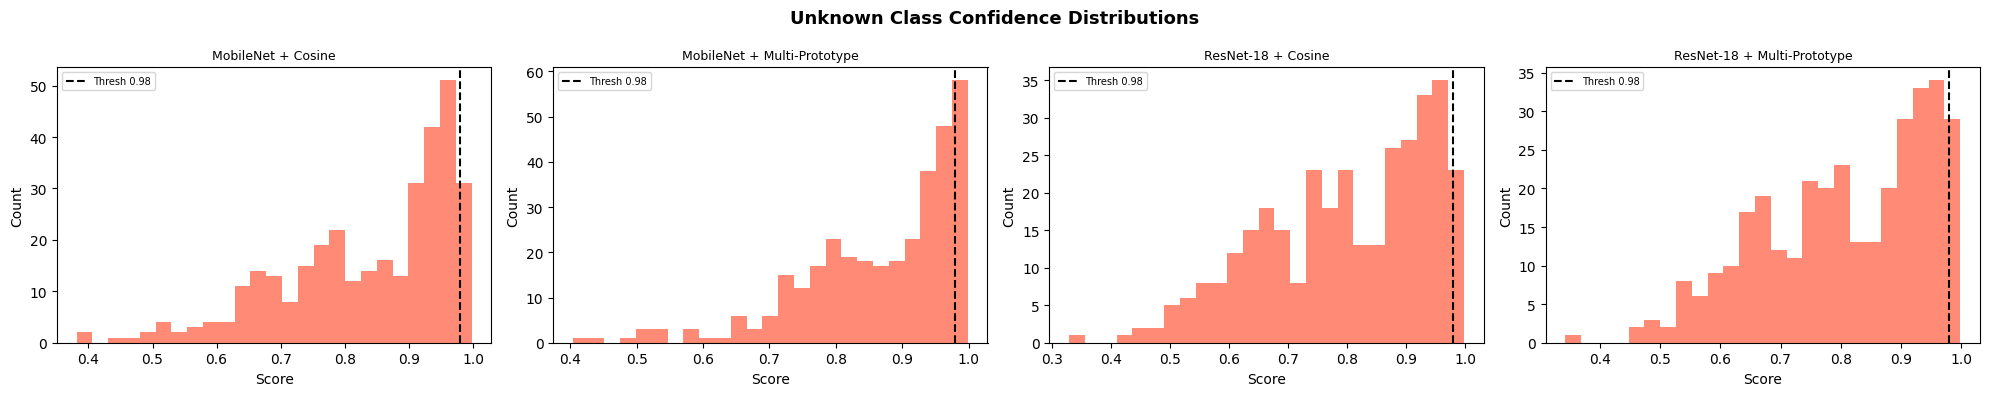

In [24]:
# Unknown-class rejection test

def collect_unknown_images(mvtec_root, known_classes, external_dir=None):
    """
    Scans mvtec_root for classes NOT in known_classes.
    Falls back to external_dir if nothing is found there.
    Supports both flat layout  (<dir>/<class>/image.png)
    and MVTec layout           (<dir>/<class>/test/good/image.png).
    """
    EXTS = {'.png', '.jpg', '.jpeg', '.bmp'}
    samples = []

    def _scan_root(root, skip_classes):
        found = []
        root = Path(root)
        if not root.exists():
            print(f'  WARNING: {root} does not exist.')
            return found
        for cls_dir in sorted(root.iterdir()):
            if not cls_dir.is_dir() or cls_dir.name in skip_classes:
                continue
            cls = cls_dir.name
            # Try MVTec layout first, then flat layout
            for sub in [cls_dir / 'test' / 'good', cls_dir]:
                imgs = [p for p in sub.iterdir() if p.suffix.lower() in EXTS] \
                       if sub.exists() else []
                if imgs:
                    for p in imgs:
                        found.append((str(p), cls))
                    print(f'  [{cls}] {len(imgs)} images  ({sub})')
                    break
        return found

    # 1. Scan MVTEC_ROOT for extra classes
    print(f'Scanning {mvtec_root} for unknown classes ...')
    samples = _scan_root(mvtec_root, known_classes)

    # 2. If still empty, try EXTERNAL_IMAGES_DIR
    if not samples and external_dir:
        print(f'  None found in MVTEC_ROOT.')
        print(f'Scanning EXTERNAL_IMAGES_DIR: {external_dir} ...')
        samples = _scan_root(external_dir, known_classes)

    if not samples:
        print('No unknown samples found.\n'
              '  → Add extra MVTec classes to MVTEC_ROOT, or\n'
              f'  → Put unknown-class folders inside:\n'
              f'     {external_dir or "EXTERNAL_IMAGES_DIR"}')
    else:
        print(f'Total unknown test images: {len(samples)}')
    return samples


# Collect
unknown_samples = collect_unknown_images(
    MVTEC_ROOT, KNOWN_CLASSES, external_dir=EXTERNAL_IMAGES_DIR
)


class UnknownDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), torch.tensor(-1, dtype=torch.long), path


if len(unknown_samples) > 0:
    unk_loader = DataLoader(
        UnknownDataset(unknown_samples, val_transform),
        batch_size=32, shuffle=False, num_workers=2
    )

    unk_rows      = []
    unk_confs_all = {}
    for model, bank, label in combos:
        preds, confs, _, _, _ = predict_batch(model, bank, unk_loader, DEVICE)
        rej  = sum(1 for p in preds if p in ('unknown', 'ambiguous'))
        tot  = len(preds)
        ucrr = rej / tot * 100
        far  = 100 - ucrr
        unk_rows.append([label, tot, rej, f'{ucrr:.2f}%', f'{far:.2f}%'])
        unk_confs_all[label] = confs

    print('\n=== Unknown-Class Rejection Comparison ===')
    print(tabulate(unk_rows,
                   headers=['Configuration', 'Total', 'Rejected', 'UCRR', 'FAR'],
                   tablefmt='fancy_grid'))

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle('Unknown Class Confidence Distributions',
                 fontsize=13, fontweight='bold')
    for ax, (model, bank, label) in zip(axes, combos):
        confs  = unk_confs_all[label]
        thresh = np.mean(list(bank.per_class_threshold.values()))
        ax.hist(confs, bins=25, color='tomato', alpha=0.75)
        ax.axvline(thresh, color='black', linestyle='--',
                   label=f'Thresh {thresh:.2f}')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Score')
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'unknown_confidence_comparison.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping unknown-class rejection test (no samples found).')

In [25]:
if len(unknown_samples) > 0:
    unk_ds     = UnknownDataset(unknown_samples, val_transform)
    unk_loader = DataLoader(unk_ds, batch_size=32, shuffle=False, num_workers=2)

    print('\n=== Unknown Sample Classification Detail ===\n')

    for model, bank, label in combos:
        preds, confs, top3s, _, paths = predict_batch(model, bank, unk_loader, DEVICE)

        class_hits = {}
        for pred, conf in zip(preds, confs):
            if pred not in class_hits:
                class_hits[pred] = {'count': 0, 'scores': []}
            class_hits[pred]['count'] += 1
            class_hits[pred]['scores'].append(conf)

        rows = []
        for cls in sorted(class_hits, key=lambda x: class_hits[x]['count'], reverse=True):
            info = class_hits[cls]
            rows.append([
                cls,
                info['count'],
                f'{np.mean(info["scores"]):.4f}',
                f'{np.min(info["scores"]):.4f}',
                f'{np.max(info["scores"]):.4f}',
            ])

        print(f'--- {label} ---')
        print(f'Total unknown samples: {len(preds)}')
        print(tabulate(
            rows,
            headers=['Predicted as', 'Count', 'Mean score', 'Min score', 'Max score'],
            tablefmt='fancy_grid'
        ))
        print()
else:
    print('No unknown samples - skipping detail breakdown.')


=== Unknown Sample Classification Detail ===



  0%|          | 0/11 [00:00<?, ?it/s]

--- MobileNet + Cosine ---
Total unknown samples: 335
╒════════════════╤═════════╤══════════════╤═════════════╤═════════════╕
│ Predicted as   │   Count │   Mean score │   Min score │   Max score │
╞════════════════╪═════════╪══════════════╪═════════════╪═════════════╡
│ unknown        │     313 │       0.8269 │      0.3816 │      0.9799 │
├────────────────┼─────────┼──────────────┼─────────────┼─────────────┤
│ wood           │      22 │       0.9878 │      0.9805 │      0.9977 │
╘════════════════╧═════════╧══════════════╧═════════════╧═════════════╛



  0%|          | 0/11 [00:00<?, ?it/s]

--- MobileNet + Multi-Prototype ---
Total unknown samples: 335
╒════════════════╤═════════╤══════════════╤═════════════╤═════════════╕
│ Predicted as   │   Count │   Mean score │   Min score │   Max score │
╞════════════════╪═════════╪══════════════╪═════════════╪═════════════╡
│ unknown        │     284 │       0.8466 │      0.4038 │      0.98   │
├────────────────┼─────────┼──────────────┼─────────────┼─────────────┤
│ wood           │      51 │       0.9914 │      0.9809 │      0.9987 │
╘════════════════╧═════════╧══════════════╧═════════════╧═════════════╛



  0%|          | 0/11 [00:00<?, ?it/s]

--- ResNet-18 + Cosine ---
Total unknown samples: 335
╒════════════════╤═════════╤══════════════╤═════════════╤═════════════╕
│ Predicted as   │   Count │   Mean score │   Min score │   Max score │
╞════════════════╪═════════╪══════════════╪═════════════╪═════════════╡
│ unknown        │     317 │       0.7881 │      0.3296 │      0.9791 │
├────────────────┼─────────┼──────────────┼─────────────┼─────────────┤
│ wood           │      13 │       0.9895 │      0.9805 │      0.998  │
├────────────────┼─────────┼──────────────┼─────────────┼─────────────┤
│ grid           │       5 │       0.9856 │      0.9809 │      0.993  │
╘════════════════╧═════════╧══════════════╧═════════════╧═════════════╛



  0%|          | 0/11 [00:00<?, ?it/s]

--- ResNet-18 + Multi-Prototype ---
Total unknown samples: 335
╒════════════════╤═════════╤══════════════╤═════════════╤═════════════╕
│ Predicted as   │   Count │   Mean score │   Min score │   Max score │
╞════════════════╪═════════╪══════════════╪═════════════╪═════════════╡
│ unknown        │     316 │       0.796  │      0.3427 │      0.9792 │
├────────────────┼─────────┼──────────────┼─────────────┼─────────────┤
│ wood           │      14 │       0.9915 │      0.9821 │      0.9985 │
├────────────────┼─────────┼──────────────┼─────────────┼─────────────┤
│ grid           │       5 │       0.9876 │      0.9826 │      0.9945 │
╘════════════════╧═════════╧══════════════╧═════════════╧═════════════╛



## 17. Embedding Space Visualization

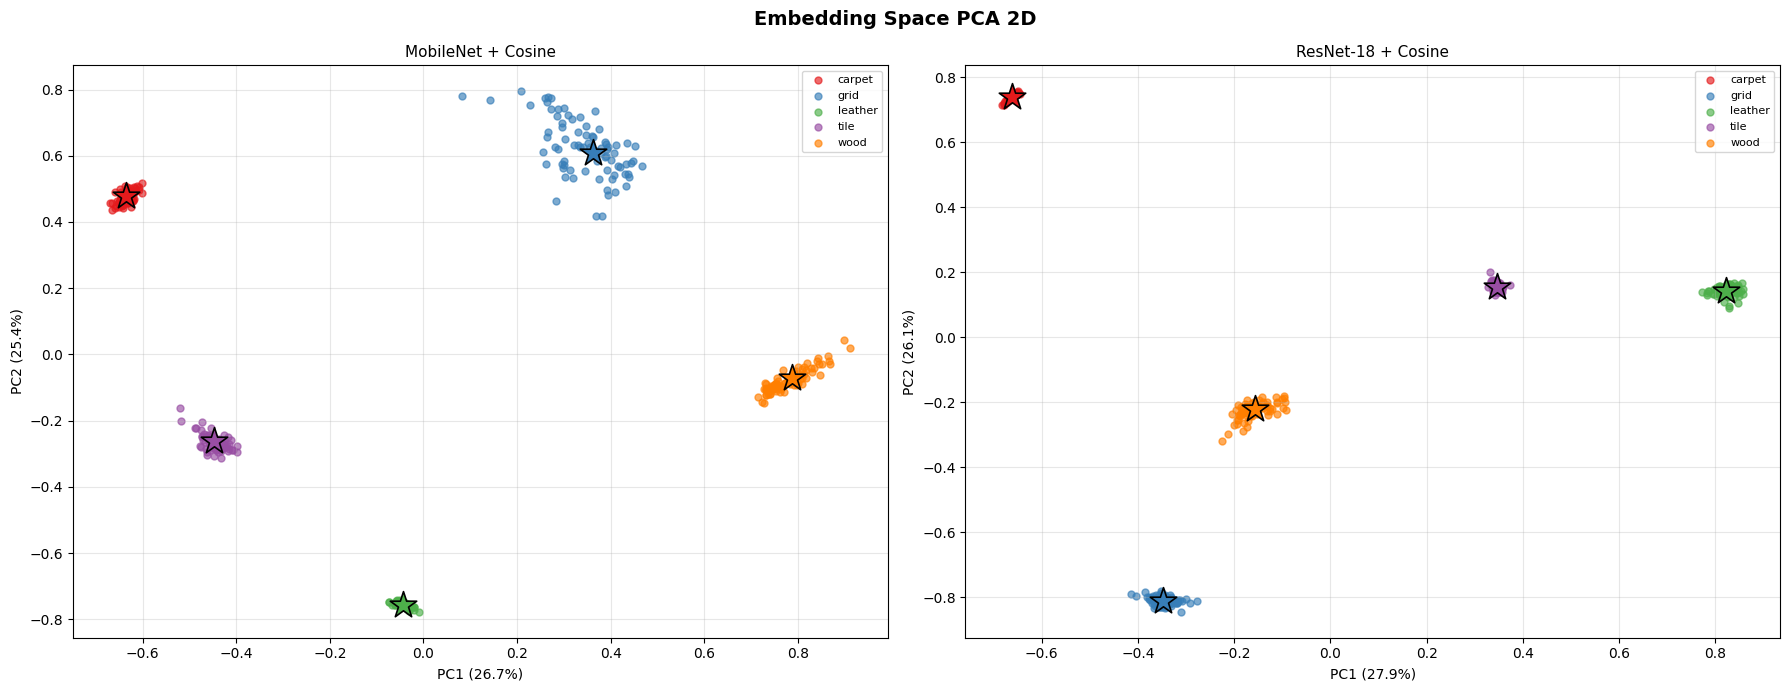

In [26]:
@torch.no_grad()
def get_embeddings(model, samples, device, max_per_class=80):
    model.eval()
    embs, labels = [], []
    per_cls = Counter()
    random.shuffle(samples)
    for path, cls in samples:
        if per_cls[cls] >= max_per_class:
            continue
        try:
            img = val_transform(Image.open(path).convert('RGB'))
            e   = model(img.unsqueeze(0).to(device),
                        return_embedding=True).squeeze(0).cpu().numpy()
            embs.append(e)
            labels.append(cls)
            per_cls[cls] += 1
        except Exception:
            continue
    return np.array(embs), labels


def plot_embedding_grid(combos_to_plot, samples):
    n   = len(combos_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(9*n, 7))
    if n == 1:
        axes = [axes]
    fig.suptitle('Embedding Space PCA 2D', fontsize=14, fontweight='bold')
    palette   = sns.color_palette('Set1', NUM_CLASSES)
    cls_color = {cls: c for cls, c in zip(sorted(KNOWN_CLASSES), palette)}

    for ax, (model, bank, label) in zip(axes, combos_to_plot):
        embs, lbls = get_embeddings(model, samples, DEVICE)
        pca = PCA(n_components=2, random_state=SEED)
        pts = pca.fit_transform(embs)
        for cls in sorted(KNOWN_CLASSES):
            idxs = [i for i, l in enumerate(lbls) if l == cls]
            ax.scatter(pts[idxs,0], pts[idxs,1],
                       color=cls_color[cls], label=cls, alpha=0.65, s=25)
        for idx, proto in bank.prototypes.items():
            p = pca.transform(proto.numpy().reshape(1,-1))[0]
            ax.scatter(p[0], p[1], color=cls_color[IDX_TO_CLASS[idx]],
                       marker='*', s=400, edgecolors='black',
                       linewidths=1.2, zorder=10)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'embedding_comparison.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


plot_embedding_grid(
    [(model_mobilenet, bank_mob_cos, 'MobileNet + Cosine'),
     (model_resnet,    bank_res_cos, 'ResNet-18 + Cosine')],
    all_train_val
)

## 18. Load Checkpoint

In [ ]:
LOAD_MODEL_PATH = './checkpoints/best_mobilenet.pth'
LOAD_BANK_PATH  = './checkpoints/bank_mobilenet_cosine.pth'


def load_full_system(model_path, bank_path, device):
    ckpt = torch.load(model_path, map_location=device)
    m    = PrototypeRecognizer(
        num_classes=ckpt['num_classes'],
        backbone_name=ckpt['backbone_name'],
        embedding_dim=ckpt['embedding_dim'],
        dropout=DROPOUT,
        pretrained=False
    ).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    bank = PrototypeBank.load(bank_path)
    print(f'Model:    {model_path}  (epoch {ckpt["epoch"]})')
    print(f'Bank:     {bank_path}')
    print(f'Backbone: {ckpt["backbone_name"]}')
    print(f'Metric:   {bank.distance_metric}')
    print(f'Classes:  {list(bank.class_to_idx.keys())}')
    return m, bank


print('Load utility ready. Uncomment to use.')


Load utility ready. Uncomment to use.


## 20. Interactive Upload

In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def run_interactive(models_banks):
    """
    models_banks: list of (model, bank, label) tuples to switch between.
    """
    selector = widgets.ToggleButtons(
        options=[label for _, _, label in models_banks],
        description='Config:',
        layout=widgets.Layout(width='600px')
    )
    uploader = widgets.FileUpload(
        accept='.png,.jpg,.jpeg,.bmp', multiple=False,
        description='Upload Image',
        layout=widgets.Layout(width='300px')
    )
    out = widgets.Output()

    def get_active():
        for model, bank, label in models_banks:
            if label == selector.value:
                return model, bank, label
        return models_banks[0]

    def run_prediction(_=None):
        with out:
            clear_output(wait=True)
            if not uploader.value:
                return
            fi      = list(uploader.value.values())[0] \
                      if isinstance(uploader.value, dict) \
                      else uploader.value[0]
            content = fi.get('content', fi.get('data', b''))
            pil     = Image.open(io.BytesIO(bytes(content))).convert('RGB')

            model, bank, config_label = get_active()

            t0 = time.perf_counter()
            label, conf, top3 = predict_single(model, bank, pil, DEVICE)
            ms = (time.perf_counter() - t0) * 1000

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            axes[0].imshow(pil)
            axes[0].axis('off')
            axes[0].set_title('Uploaded Image')

            if top3:
                top_labels = [t[0] for t in top3]
                top_scores = [t[1] for t in top3]
                bar_colors = [
                    'steelblue' if l not in ('unknown', 'ambiguous') else 'tomato'
                    for l in top_labels
                ]
                bars = axes[1].barh(top_labels[::-1], top_scores[::-1],
                                    color=bar_colors[::-1])
                thresh = bank.per_class_threshold.get(
                    bank.class_to_idx.get(top_labels[0], -1),
                    CONFIDENCE_THRESHOLD
                )
                axes[1].axvline(thresh, color='black', linestyle='--',
                                label=f'Threshold ({thresh:.2f})')
                for bar, sc in zip(bars[::-1], top_scores):
                    axes[1].text(
                        bar.get_width() + 0.01,
                        bar.get_y() + bar.get_height() / 2,
                        f'{sc:.4f}', va='center', fontsize=10
                    )
                axes[1].set_xlabel('Score')
                axes[1].set_title(f'Top 3  [{bank.distance_metric}]')
                axes[1].legend()

            color = 'green' if label not in ('unknown', 'ambiguous') else 'red'
            fig.suptitle(
                f'Prediction: {label.upper()}  |  Score: {conf:.4f}  |  '
                f'{ms:.1f} ms  |  Config: {config_label}',
                fontsize=13, fontweight='bold', color=color, y=1.02
            )
            plt.tight_layout()
            plt.show()

            print(tabulate(
                [['Prediction',      label.upper()],
                 ['Score',           f'{conf:.4f}'],
                 ['Status',          'ACCEPTED' if label not in ('unknown', 'ambiguous')
                                     else 'REJECTED'],
                 ['Config',          config_label],
                 ['Distance Metric', bank.distance_metric],
                 ['Inference Time',  f'{ms:.2f} ms']] +
                [[f'Top {i+1}', f'{c} ({s:.4f})'] for i, (c, s) in enumerate(top3)],
                headers=['Field', 'Value'], tablefmt='fancy_grid'
            ))

    selector.observe(lambda _: run_prediction(), names='value')
    uploader.observe(lambda _: run_prediction(), names='value')

    display(widgets.VBox([selector, uploader, out]))


run_interactive([
    (model_resnet, bank_res_cos, 'ResNet-18 + Cosine'),
    (model_resnet, bank_res_mpr, 'ResNet-18 + Multi-Prototype'),
])